# Modeling — Predicting Electric Vehicle Purchases

Continues from [EDA.ipynb](EDA.ipynb). Metric: **ROC AUC** on `Will_Buy_EV`. AUC only scores the
*ranking* of the predicted probabilities, so calibration, thresholds and class weights don't change it.

## From EDA to modeling decisions

| EDA finding | Decision in this notebook |
|---|---|
| 668,665 train / 286,571 test rows, no missing values | No imputation. |
| Imbalanced target: 17.5% `Yes` | Stratified folds. No resampling or class weights — AUC ignores calibration. |
| `Subsidy_Available = No` → 0.6% buy rate vs 27% with a subsidy | Looks like a gate. §4 tests one model per subsidy segment; §5 measures how much interactions matter at all. |
| `Environmental_Concern_Level` is the strongest signal (corr 0.46): the buy rate climbs from 0.6% to 52% over its 5 levels | Not a straight line in the level → one-hot it for the linear model. |
| `Range_Anxiety_Level`: Low 19% / Medium 4% / High ≈ 0% | One-hot for the linear model; trees split on it natively. |
| `Annual_Income_USD` is the second numeric signal (corr 0.23) | Splines for the linear model, and the focus of feature engineering in §6. |
| Histogram spikes at the minimum: income = 30,000 (9% of rows), commute = 5 km (22%) | The generator clips values → §6 tests explicit floor flags. |
| Age, gender, car type, cars owned and charging stations barely move the buy rate | Kept; the models decide. |
| Train/test feature means agree within 0.3% | §2 confirms with adversarial validation. |

Two things the EDA did not cover:
- **Duplicates.** The EDA's `train.duplicated()` included the unique `id` column, so it could never
  find a duplicate. §1 re-checks on the features only.
- **Synthetic origin.** The competition data was generated from the 10,000-row
  [EV Adoption Behavior and Range Anxiety](https://www.kaggle.com/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety)
  survey. Generated data can carry artifacts of the generator — for example in how often exact values
  repeat — and those are worth testing directly (§6).

## Plan

0. Setup
1. Load data
2. Adversarial validation
3. Cross-validation framework
4. Linear baselines — plain vs EDA-informed logistic regression
5. Gradient boosting baselines — LightGBM / XGBoost / CatBoost, and how much interactions matter
6. Feature engineering — ideas from the EDA and from the synthetic origin, each tested on the same folds;
   ends with the *wide encoding* and a test of more training rows per fold
7. Hyperparameter tuning — Optuna for all three boosters, on the wide encoding
8. Final models — 10-fold CV
9. Ensemble
10. Interpretation — SHAP
11. Diagnostics — ROC, calibration, AUC by segment
12. Submission
13. Summary

**Runtime:** roughly 1.5 hours on an 8-core laptop (Apple M2). Sections 1–6 take about 25 minutes; tuning
(§7) and the final models (§8) take most of the rest. Re-runs can skip tuning with `RUN_TUNING = False`.

The notes after each section quote numbers from development runs on the same folds and seed; a full run
reproduces them up to small differences.

## 0. Setup

In [1]:
import inspect
import json
import re
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")  # set before importing optuna, which triggers tqdm's IProgress warning

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit, logit

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    SplineTransformer,
    StandardScaler,
    TargetEncoder,
)

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

NOTEBOOK_START = time.time()
SEED = 42
N_SPLITS = 5
# §8–9 fit the final models on 10 folds: each fold model — and its target encoders — then trains on 90% of
# the rows instead of 80%, which sharpens the per-value encodings (§6 measures the gain). The experiments in
# §4–7 stay on 5 folds, where they are twice as cheap and their paired comparisons are already sharp.
FINAL_SPLITS = 10
TARGET = "Will_Buy_EV"
DATA_DIR = Path("playground-series-s6e9")
# Optional original survey (§1, §6):
#   kaggle datasets download -d itzzomkar/ev-adoption-behavior-and-range-anxiety -p original-data --unzip
ORIGINAL_PATH = Path("original-data/EV_Adoption_and_Range_Anxiety_Dataset.csv")
ARTIFACTS = Path("artifacts")
(ARTIFACTS / "preds").mkdir(parents=True, exist_ok=True)

# Tuning (§7) is the slowest section. Trials are stored in artifacts/optuna.db, so a stopped or
# repeated run resumes instead of starting over. RUN_TUNING = False reuses artifacts/best_params.json.
RUN_TUNING = True
N_TRIALS = {"lightgbm": 30, "xgboost": 20, "catboost": 10}

# §8 fits every final booster once per seed on each fold and averages the fits: a cheap ensemble that
# steadies the predictions. Each extra seed is another full training run, e.g. [42, 7, 2026] is 3x slower.
FINAL_SEEDS = [SEED]

# Chart colors in a fixed order (colorblind-checked); single-series charts use the first.
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
rng = np.random.default_rng(SEED)

print("lightgbm", lgb.__version__, "| xgboost", xgb.__version__, "| optuna", optuna.__version__)

lightgbm 4.6.0 | xgboost 3.1.3 | optuna 4.8.0


## 1. Load data

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

NUMERIC_COLS = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level",
]
CATEGORICAL_COLS = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level",
]
FEATURES = NUMERIC_COLS + CATEGORICAL_COLS

y = (train[TARGET] == "Yes").astype(int).values

print("train:", train.shape, " test:", test.shape)
print(f"positive rate: {y.mean():.5f}")
print("duplicate feature rows in train   :", train.duplicated(FEATURES).sum())
print("test rows identical to a train row:", len(test[FEATURES].merge(train[FEATURES], how="inner")))

train: (668665, 15)  test: (286571, 14)
positive rate: 0.17465
duplicate feature rows in train   : 0


test rows identical to a train row: 0


### The original survey

Optional: if the CSV is missing, the one experiment that uses it (§6) is skipped.

In [3]:
def buy_rate(df, col):
    return df.groupby(col)[TARGET].apply(lambda s: (s == "Yes").mean())


if ORIGINAL_PATH.exists():
    original = pd.read_csv(ORIGINAL_PATH)
    y_original = (original[TARGET] == "Yes").astype(int).values
    print("original:", original.shape, f"| positive rate {y_original.mean():.4f}")
    print("missing values:", original[FEATURES].isnull().sum().loc[lambda s: s > 0].to_dict())

    rate_table = pd.concat(
        {
            col: pd.DataFrame(
                {"competition train": buy_rate(train, col), "original survey": buy_rate(original, col)}
            )
            for col in ["Subsidy_Available", "Range_Anxiety_Level", "Environmental_Concern_Level"]
        }
    )
    display(rate_table.round(4))
else:
    original = None
    print(f"{ORIGINAL_PATH} not found — the original-survey experiment in §6 is skipped.")

original: (10000, 15) | positive rate 0.1750
missing values: {'Annual_Income_USD': 178, 'Daily_Commute_km': 181, 'Environmental_Concern_Level': 184}


competition train  original survey
Subsidy_Available           No                 0.0058           0.0253
                            Yes                0.2747           0.2745
Range_Anxiety_Level         High               0.0014           0.0060
                            Low                0.1890           0.1987
                            Medium             0.0417           0.0643
Environmental_Concern_Level 1.0                0.0057           0.0214
                            2.0                0.0214           0.0493
                            3.0                0.1109           0.1445
                            4.0                0.2488           0.2529
                            5.0                0.5183           0.4140

**Notes (development run).** The survey has the same overall buy rate (17.5%) but noticeably *weaker*
relationships than the synthetic data: without a subsidy 2.5% of survey respondents buy vs 0.6% in the
competition data, and at environmental-concern level 5 it is 41% vs 52%. The survey also has ~180 missing
values in each of income, commute and concern level; the competition data has none. So the survey comes
from a visibly different distribution — §6 checks whether its rows help anyway.

## 2. Adversarial validation

The EDA compared train and test feature *means*. A stronger check: train a classifier to tell train
rows from test rows. An AUC near 0.5 means it can't, so the test set comes from the same distribution
and cross-validation scores should carry over to the leaderboard.

In [4]:
adv_X = pd.concat([train[FEATURES], test[FEATURES]], ignore_index=True)
for col in CATEGORICAL_COLS:
    adv_X[col] = adv_X[col].astype("category")
adv_y = np.r_[np.zeros(len(train)), np.ones(len(test))]

adv_oof = np.zeros(len(adv_X))
for trn_idx, val_idx in StratifiedKFold(3, shuffle=True, random_state=SEED).split(adv_X, adv_y):
    adv_model = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.1, num_leaves=63, random_state=SEED, n_jobs=-1, verbose=-1
    )
    adv_model.fit(adv_X.iloc[trn_idx], adv_y[trn_idx])
    adv_oof[val_idx] = adv_model.predict_proba(adv_X.iloc[val_idx])[:, 1]

print(f"adversarial AUC (train vs test): {roc_auc_score(adv_y, adv_oof):.4f}")

adversarial AUC (train vs test): 0.4998


**How to read it.** An AUC close to 0.5 means the classifier can't tell train rows from test rows, so the
CV scores below are fair estimates of leaderboard performance. If it were clearly higher (say above 0.55),
the adversarial model's feature importances would point at the shifted feature — investigate that before
trusting CV.

## 3. Cross-validation framework

`StratifiedKFold(5, shuffle=True)`, with the same folds for every model so all comparisons are
apples-to-apples. `cross_validate_model` collects out-of-fold (OOF) predictions for the AUC estimate and
averages the fold models' test predictions into a submission candidate. The final models' predictions
are also saved to `artifacts/preds/`, so they can be blended later without retraining.

**Comparing two models.** Fold AUCs vary by roughly ±0.0008, but most of that is how hard each fold
happens to be, and every model scored on that fold shares it. The per-fold *difference* between two
models is a much sharper yardstick, so `compare()` reports its mean ± std across the 5 folds. A change is
worth keeping when the mean clearly exceeds the std and the sign agrees across folds.

**Final folds.** §8–9 score on `final_folds` — 10 folds from the same seed — by passing
`split=final_folds`. A paired comparison needs both runs on the same folds, so `compare()` refuses runs
from different schemes; across schemes, compare the pooled OOF AUC.

In [5]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = list(skf.split(train, y))
final_folds = list(StratifiedKFold(n_splits=FINAL_SPLITS, shuffle=True, random_state=SEED).split(train, y))

results = {}

# LightGBM 4.7 renamed the validation arguments of `fit()` from `eval_set` to
# `eval_X`/`eval_y`; 4.6 and earlier only accept `eval_set`. Detect which one this
# install expects so the notebook runs on either version.
_LGB_USES_EVAL_XY = "eval_X" in inspect.signature(lgb.LGBMClassifier.fit).parameters


def lgb_fit(model, X_trn, y_trn, X_val, y_val, stopping_rounds=150):
    """Fit a LGBMClassifier with early stopping, across LightGBM versions."""
    eval_kwargs = (
        {"eval_X": X_val, "eval_y": y_val}
        if _LGB_USES_EVAL_XY
        else {"eval_set": [(X_val, y_val)]}
    )
    model.fit(
        X_trn,
        y_trn,
        eval_metric="auc",
        callbacks=[lgb.early_stopping(stopping_rounds, verbose=False)],
        **eval_kwargs,
    )
    return model


def store_result(name, oof, test_pred, best_iters=None, seconds=0.0, save=False, split=None):
    split = folds if split is None else split
    fold_aucs = [roc_auc_score(y[v], oof[v]) for _, v in split]
    results[name] = {
        "oof": oof,
        "test_pred": test_pred,
        "auc": roc_auc_score(y, oof),
        "fold_aucs": fold_aucs,
        "best_iters": best_iters or [None] * len(split),
        "seconds": seconds,
    }
    if save:
        slug = re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")
        np.savez_compressed(
            ARTIFACTS / "preds" / f"{slug}.npz", oof=oof.astype(np.float32), test_pred=test_pred.astype(np.float32)
        )
    return results[name]


def cross_validate_model(name, fit_fold, X_tr, X_te, save=False, split=None):
    """Run K-fold CV on `split` (default: the 5 experiment folds).
    `fit_fold(X_trn, y_trn, X_val, y_val)` returns (predict_fn, best_iter)."""
    split = folds if split is None else split
    start = time.time()
    oof = np.zeros(len(X_tr))
    test_pred = np.zeros(len(X_te))
    best_iters = []

    for trn_idx, val_idx in split:
        predict, best_iter = fit_fold(
            X_tr.iloc[trn_idx], y[trn_idx], X_tr.iloc[val_idx], y[val_idx]
        )
        oof[val_idx] = predict(X_tr.iloc[val_idx])
        test_pred += predict(X_te) / len(split)
        best_iters.append(best_iter)

    r = store_result(name, oof, test_pred, best_iters, time.time() - start, save, split)
    print(f"{name:38s} OOF AUC = {r['auc']:.5f}  (fold std {np.std(r['fold_aucs']):.5f})  {r['seconds']:.1f}s")
    if any(b is not None for b in best_iters):
        print(f"{'':38s} best iterations: {best_iters}")
    return r["auc"]


def compare(base, new):
    """Paired comparison of two stored CV runs on the same folds."""
    if len(results[new]["fold_aucs"]) != len(results[base]["fold_aucs"]):
        raise ValueError(f"{base!r} and {new!r} used different folds — compare their pooled OOF AUC instead")
    delta = np.array(results[new]["fold_aucs"]) - np.array(results[base]["fold_aucs"])
    print(f"{new}  vs  {base}: {delta.mean():+.5f} ± {delta.std(ddof=1):.5f}   per fold {np.round(delta, 5)}")
    return delta


def plot_auc(names, title):
    """Dot plot of OOF AUC. The differences live in the 4th decimal, so bars from zero would hide them."""
    table = pd.Series({n: results[n]["auc"] for n in names}).sort_values()
    lo = table.min() - 0.001
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(table) + 1.4))
    ax.hlines(range(len(table)), lo, table.values, color="0.85", lw=1)
    ax.plot(table.values, range(len(table)), "o", color=COLORS[0], markersize=8)
    for i, v in enumerate(table.values):
        ax.annotate(f"{v:.5f}", (v, i), xytext=(8, 0), textcoords="offset points", va="center", fontsize=9)
    ax.set_yticks(range(len(table)), table.index)
    ax.set_xlim(lo, table.max() + 0.0012)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("OOF ROC AUC")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def to_logit(p):
    return logit(np.clip(p, 1e-7, 1 - 1e-7))

In [6]:
CATEGORY_LEVELS = {col: sorted(set(train[col]) | set(test[col])) for col in CATEGORICAL_COLS}


def tree_frame(df):
    """Features with categoricals as pandas `category`, levels shared by train and test (LightGBM / XGBoost)."""
    out = df[FEATURES].copy()
    for col in CATEGORICAL_COLS:
        out[col] = pd.Categorical(out[col], categories=CATEGORY_LEVELS[col])
    return out


def catboost_frame(df):
    """CatBoost takes its categorical features as plain strings."""
    return df.astype({col: str for col in CATEGORICAL_COLS})


X, X_test = tree_frame(train), tree_frame(test)
X.dtypes

Age                               int64
Annual_Income_USD               float64
Daily_Commute_km                float64
Number_of_Cars_Owned              int64
Charging_Stations_Near_Home       int64
Charging_Stations_Near_Work       int64
Environmental_Concern_Level     float64
Gender                         category
City_Type                      category
Current_Car_Type               category
Home_Charging_Possible         category
Subsidy_Available              category
Range_Anxiety_Level            category
dtype: object

## 4. Linear baselines

- **Plain:** scaled numerics + one-hot categoricals — the baseline from the first version of this notebook.
- **EDA splines:** the EDA showed effects a straight line can't follow — the buy rate jumps between
  environmental-concern levels, income and commute have clipped floors, and station/car counts are small
  discrete sets. So: cubic splines for income, commute and age; one-hot for every discrete column; and
  explicit floor flags.
- **Per subsidy segment:** without a subsidy almost nobody buys. If subsidy *gates* the other effects,
  a separate model per segment should beat one shared model.

In [7]:
DISCRETE_NUMERIC_COLS = [
    "Environmental_Concern_Level",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
]
INCOME_FLOOR = train["Annual_Income_USD"].min()
COMMUTE_FLOOR = train["Daily_Commute_km"].min()


def add_floor_flags(df):
    """The EDA histograms spike at the minimum income and commute: values clipped by the generator."""
    return df.assign(
        Income_at_floor=(df["Annual_Income_USD"] <= INCOME_FLOOR).astype(int),
        Commute_at_floor=(df["Daily_Commute_km"] <= COMMUTE_FLOOR).astype(int),
    )


def lr_plain():
    pre = ColumnTransformer(
        [
            ("num", StandardScaler(), NUMERIC_COLS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
        ]
    )
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000, random_state=SEED))])


def lr_eda(income_features=False):
    """Splines + one-hot + floor flags; optionally splines on the §6 income features too."""
    def spline():
        return SplineTransformer(n_knots=12, degree=3, extrapolation="constant")

    blocks = [
        ("spline", spline(), ["Annual_Income_USD", "Daily_Commute_km", "Age"]),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLS + DISCRETE_NUMERIC_COLS),
        ("flags", "passthrough", ["Income_at_floor", "Commute_at_floor"]),
    ]
    if income_features:
        blocks += [
            ("income_count", make_pipeline(FunctionTransformer(np.log1p), spline()), ["Income_count"]),
            ("income_te", make_pipeline(FunctionTransformer(to_logit), spline()), ["Annual_Income_USD_te"]),
        ]
    pre = ColumnTransformer(blocks, sparse_threshold=0)
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=3000, random_state=SEED))])


class PerSegmentModel:
    """One model per level of `segment_col`, each fit only on that segment's rows."""

    def __init__(self, make_model, segment_col):
        self.make_model = make_model
        self.segment_col = segment_col

    def fit(self, X, y):
        self.models_ = {}
        for level in X[self.segment_col].unique():
            mask = (X[self.segment_col] == level).values
            self.models_[level] = self.make_model().fit(X[mask], y[mask])
        return self

    def predict_proba(self, X):
        proba = np.zeros((len(X), 2))
        for level, model in self.models_.items():
            mask = (X[self.segment_col] == level).values
            if mask.any():
                proba[mask] = model.predict_proba(X[mask])
        return proba


def sklearn_fold_factory(make_model):
    def fit_fold(X_trn, y_trn, X_val, y_val):
        model = make_model().fit(X_trn, y_trn)
        return (lambda d: model.predict_proba(d)[:, 1]), None

    return fit_fold


X_lr, X_test_lr = add_floor_flags(train[FEATURES]), add_floor_flags(test[FEATURES])

cross_validate_model("LogReg (plain)", sklearn_fold_factory(lr_plain), X_lr, X_test_lr)
cross_validate_model("LogReg (EDA splines)", sklearn_fold_factory(lr_eda), X_lr, X_test_lr)
cross_validate_model(
    "LogReg (EDA splines, per subsidy)",
    sklearn_fold_factory(lambda: PerSegmentModel(lr_eda, "Subsidy_Available")),
    X_lr,
    X_test_lr,
)
print()
compare("LogReg (plain)", "LogReg (EDA splines)")
compare("LogReg (EDA splines)", "LogReg (EDA splines, per subsidy)");

LogReg (plain)                         OOF AUC = 0.93809  (fold std 0.00081)  7.6s


LogReg (EDA splines)                   OOF AUC = 0.93929  (fold std 0.00079)  20.5s


LogReg (EDA splines, per subsidy)      OOF AUC = 0.93927  (fold std 0.00078)  20.3s

LogReg (EDA splines)  vs  LogReg (plain): +0.00120 ± 0.00012   per fold [0.00132 0.00105 0.00132 0.00111 0.0012 ]
LogReg (EDA splines, per subsidy)  vs  LogReg (EDA splines): -0.00002 ± 0.00006   per fold [-1.0e-05 -3.0e-05 -2.0e-05 -1.1e-04  6.0e-05]


**Notes (development runs).** Plain 0.93809 → EDA splines 0.93929: **+0.0012 ± 0.0001**, better on every
fold, so the non-linear shapes the EDA showed are real. The per-subsidy variant scores 0.93927
(−0.00002 ± 0.00006): the gate-like subsidy pattern does *not* need separate models. That points to an
additive effect — no subsidy lowers everyone's log-odds by a similar amount instead of switching the other
features off — so splitting the data only leaves each model fewer rows to learn from. §5 tests the
additivity directly.

## 5. Gradient boosting baselines

Same folds, early stopping on the validation fold (`n_estimators` is only an upper bound).

- **LightGBM** uses the tree shape Optuna found in the first version of this notebook (16 leaves, strong
  regularization) at a fast learning rate of 0.08. It is the reference model for every experiment in §6.
- **XGBoost** and **CatBoost** use the first version's settings. Every categorical has at most 4 levels, so
  CatBoost's `one_hot_max_size=10` one-hot encodes them all and skips its target statistics; with
  `boosting_type="Plain"` that is much faster at the same AUC.

In [8]:
LGB_BASE_PARAMS = dict(
    n_estimators=4000,
    learning_rate=0.08,
    num_leaves=16,
    min_child_samples=178,
    feature_fraction=0.63,
    bagging_fraction=0.65,
    bagging_freq=1,
    lambda_l1=2.2,
    lambda_l2=5.1,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)


def lgbm_fold_factory(params=None, stopping_rounds=150):
    config = {**LGB_BASE_PARAMS, **(params or {})}

    def fit_fold(X_trn, y_trn, X_val, y_val):
        model = lgb_fit(lgb.LGBMClassifier(**config), X_trn, y_trn, X_val, y_val, stopping_rounds)
        return (lambda d: model.predict_proba(d)[:, 1]), model.best_iteration_

    return fit_fold


cross_validate_model("LightGBM", lgbm_fold_factory(), X, X_test);

LightGBM                               OOF AUC = 0.94200  (fold std 0.00079)  58.6s
                                       best iterations: [575, 693, 601, 644, 747]


In [9]:
XGB_BASE_PARAMS = dict(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=7,
    tree_method="hist",
    enable_categorical=True,
    eval_metric="auc",
    random_state=SEED,
    n_jobs=-1,
)


def xgb_fold_factory(params=None, stopping_rounds=100):
    config = {**XGB_BASE_PARAMS, **(params or {})}

    def fit_fold(X_trn, y_trn, X_val, y_val):
        model = xgb.XGBClassifier(early_stopping_rounds=stopping_rounds, **config)
        model.fit(X_trn, y_trn, eval_set=[(X_val, y_val)], verbose=False)
        return (lambda d: model.predict_proba(d)[:, 1]), model.best_iteration

    return fit_fold


cross_validate_model("XGBoost", xgb_fold_factory(), X, X_test);

XGBoost                                OOF AUC = 0.94154  (fold std 0.00074)  47.4s
                                       best iterations: [407, 354, 357, 357, 346]


In [10]:
CATBOOST_BASE_PARAMS = dict(
    iterations=1500,
    learning_rate=0.1,
    depth=6,
    eval_metric="AUC",
    cat_features=CATEGORICAL_COLS,
    one_hot_max_size=10,
    boosting_type="Plain",
    random_seed=SEED,
    thread_count=-1,
    verbose=0,
    allow_writing_files=False,  # no catboost_info/ folder
)


def catboost_fold_factory(params=None, stopping_rounds=100):
    config = {**CATBOOST_BASE_PARAMS, **(params or {})}

    def fit_fold(X_trn, y_trn, X_val, y_val):
        model = CatBoostClassifier(early_stopping_rounds=stopping_rounds, **config)
        model.fit(catboost_frame(X_trn), y_trn, eval_set=(catboost_frame(X_val), y_val))
        return (lambda d: model.predict_proba(catboost_frame(d))[:, 1]), model.get_best_iteration()

    return fit_fold


cross_validate_model("CatBoost", catboost_fold_factory(), X, X_test);

CatBoost                               OOF AUC = 0.94174  (fold std 0.00076)  108.6s
                                       best iterations: [630, 611, 817, 661, 500]


### How much do interactions matter?

Depth-1 trees (stumps) each look at a single feature, so a boosted model built from them is *additive*:
it can learn any shape per feature but no interaction between features. If that loses little AUC, the
signal is essentially a sum of per-feature effects — and effort should go into representing individual
features better rather than crossing them.

LightGBM depth-1 (additive)            OOF AUC = 0.94183  (fold std 0.00078)  189.4s
                                       best iterations: [4605, 5590, 5291, 4380, 5045]
LightGBM  vs  LightGBM depth-1 (additive): +0.00017 ± 0.00005   per fold [0.00015 0.00015 0.00014 0.00026 0.00014]


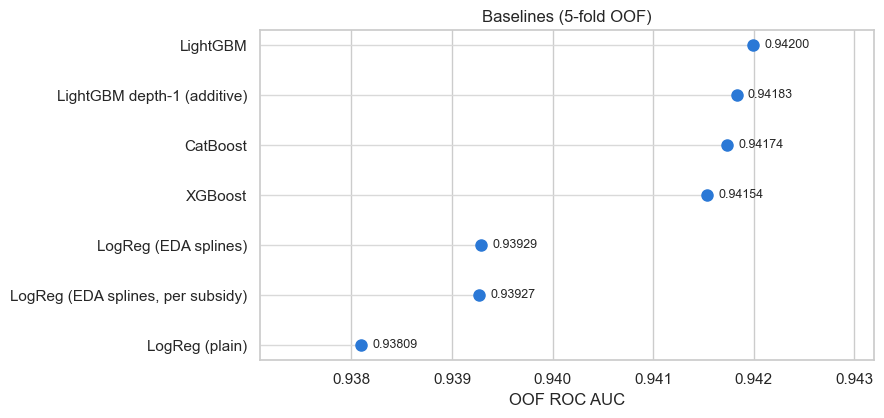

In [11]:
cross_validate_model(
    "LightGBM depth-1 (additive)",
    lgbm_fold_factory(dict(max_depth=1, num_leaves=2, min_child_samples=20, learning_rate=0.3, n_estimators=8000)),
    X,
    X_test,
)
compare("LightGBM depth-1 (additive)", "LightGBM")

plot_auc(list(results), "Baselines (5-fold OOF)")

**Notes (development runs).** On the raw features the three boosters land within 0.0005 of each other —
LightGBM 0.94200, CatBoost 0.94174, XGBoost 0.94154 — about +0.0027 over the EDA-spline logistic
regression. The depth-1 LightGBM scores 0.94183, only **0.00017 ± 0.00005** below the full LightGBM.
Almost all of the signal is additive, a sum of per-feature effects, which is also why the per-subsidy
models in §4 didn't help. The headroom is in how individual features are represented rather than in
crossing them, and that is where §6 looks.

## 6. Feature engineering

Each experiment adds one idea to the §5 LightGBM — same parameters, same folds — and is judged by its
paired gain. Ideas are tagged by where they came from, since that changes how much to trust them going in:
our own EDA and this notebook's own analysis are grounded in this specific dataset; community ideas are
borrowed reasoning that still has to earn its place through the same ablation as everything else.

**Ideas from our own EDA** ([EDA.ipynb](EDA.ipynb))
- *Floor flags:* the clipped income/commute spikes as explicit indicators.
- *Discrete numerics as categories:* age, environmental concern, cars owned and station counts take only
  4–45 values; as categories LightGBM can group non-adjacent values in one split.

**Ideas from our own analysis in this notebook** (not in EDA.ipynb — done directly in §1/§6 below)
- *Original survey rows:* append the 10,000 real rows to every training fold (never to the validation fold).
- *Income value frequency* and *income target encoding* — motivated by the closer look at income below.
- *Value pools:* where the generator draws each column's values from, and whether it copies whole survey
  rows — the check that motivates the wide encoding below.
- *More training rows per fold* (10 folds instead of 5), because every target encoding is a per-value
  average that gets sharper with more rows.

**Ideas from the community** — found in a higher-scoring public notebook on this competition
([`pure-lgbm-model-cv-0-94607-lb-0-94638.ipynb`](pure-lgbm-model-cv-0-94607-lb-0-94638.ipynb)), which in
turn credited two Kaggle discussion threads. Not copied as-is: each idea was re-verified/re-scoped against
*our own* data before use, and each was kept or dropped by the same ablation as everything else in this
section (§6.3–6.5 below), independent of what the source notebook reported.
- *Magic threshold flags:* the millionaire cliff (income ≥ 170,537, 100% buy rate) and the income dead
  zone (38k–42k, ~0% buy rate) — credited in the source notebook to a Kaggle discussion by *starkhushi*
  and *Tilii*. The env-hater flag is our own extension of the same idea, not from that thread.
- *Original survey means:* per-level buy rate from the same survey, as a feature instead of extra rows —
  the source notebook does this (`_org_mean`) for every column; we scoped it down to the columns with
  enough original-survey rows per level to trust (≥150), leaving out the two continuous columns it also
  included.
- *Target encoding the categorical columns too*, not just income — the source notebook target-encodes
  every column this way; we test it here as its own experiment before deciding whether to keep it.
- *Multi-scale income/commute bins*, target-encoded at two extra smoothing levels (10, 100) — credited in
  the source notebook to *Markus.JM*'s "CTBoost Astra baseline."
- *Wide encoding:* every column's exact value (plus the bins) as a key, each frequency-encoded and
  target-encoded at three smoothing levels, fit by a LightGBM shaped for many correlated columns — the
  core of the source notebook, which credits *cstdy* for its target-encoding strategy and *Evgeniy
  Dvorkin* for frequency-encoding every feature. We re-implement it on our fold-safe encoders; the digit
  features and every-column survey means it also uses were dropped after they didn't help.

In [12]:
X_flags, X_test_flags = add_floor_flags(X), add_floor_flags(X_test)
cross_validate_model("LightGBM + floor flags", lgbm_fold_factory(), X_flags, X_test_flags)


def add_discrete_as_category(df):
    out = df.copy()
    for col in ["Age"] + DISCRETE_NUMERIC_COLS:
        out[f"{col}_cat"] = pd.Categorical(df[col], categories=sorted(set(train[col]) | set(test[col])))
    return out


X_dcat, X_test_dcat = add_discrete_as_category(X), add_discrete_as_category(X_test)
cross_validate_model("LightGBM + discrete as category", lgbm_fold_factory(), X_dcat, X_test_dcat)

if original is not None:
    X_original = tree_frame(original)

    def lgbm_with_original_rows(X_trn, y_trn, X_val, y_val):
        X_aug = pd.concat([X_trn, X_original], ignore_index=True)
        return lgbm_fold_factory()(X_aug, np.r_[y_trn, y_original], X_val, y_val)

    cross_validate_model("LightGBM + original rows", lgbm_with_original_rows, X, X_test)

print()
for name in ["LightGBM + floor flags", "LightGBM + discrete as category", "LightGBM + original rows"]:
    if name in results:
        compare("LightGBM", name)

LightGBM + floor flags                 OOF AUC = 0.94196  (fold std 0.00079)  55.3s
                                       best iterations: [632, 570, 577, 535, 557]


LightGBM + discrete as category        OOF AUC = 0.94135  (fold std 0.00082)  41.0s
                                       best iterations: [548, 391, 413, 386, 294]


LightGBM + original rows               OOF AUC = 0.94198  (fold std 0.00069)  50.2s
                                       best iterations: [694, 661, 523, 495, 604]

LightGBM + floor flags  vs  LightGBM: -0.00003 ± 0.00002   per fold [-3.e-05 -1.e-05 -3.e-05 -5.e-05 -4.e-05]
LightGBM + discrete as category  vs  LightGBM: -0.00064 ± 0.00009   per fold [-0.00061 -0.00078 -0.00053 -0.00065 -0.00063]
LightGBM + original rows  vs  LightGBM: -0.00001 ± 0.00014   per fold [ 2.3e-04 -2.0e-05 -6.0e-05 -1.1e-04 -8.0e-05]


In [13]:
def add_magic_flags(df):
    """Point anomalies verified on this exact income/concern scale: a 100% buy-rate cliff above
    170,537, a near-zero dead zone at 38k-42k, and near-zero buyers among the most
    environment-hostile respondents. Cliff/dead-zone thresholds are a community idea (see §6 intro:
    credited there to a Kaggle discussion by starkhushi/Tilii), re-verified against our own train.csv
    before use; the env-hater flag is our own extension of it."""
    return df.assign(
        Income_millionaire_cliff=(df["Annual_Income_USD"] >= 170537).astype(int),
        Income_dead_zone=df["Annual_Income_USD"].between(38000, 42000).astype(int),
        Env_hater=(df["Environmental_Concern_Level"] == 1).astype(int),
    )


X_magic, X_test_magic = add_magic_flags(X), add_magic_flags(X_test)
cross_validate_model("LightGBM + magic flags", lgbm_fold_factory(), X_magic, X_test_magic)
compare("LightGBM", "LightGBM + magic flags")

LightGBM + magic flags                 OOF AUC = 0.94207  (fold std 0.00079)  56.4s
                                       best iterations: [714, 718, 595, 534, 535]
LightGBM + magic flags  vs  LightGBM: +0.00008 ± 0.00001   per fold [9.e-05 6.e-05 8.e-05 7.e-05 8.e-05]


array([9.16936265e-05, 5.85492773e-05, 8.49984317e-05, 6.57743554e-05,
       7.80518678e-05])

In [14]:
ORG_MEAN_COLS = CATEGORICAL_COLS + DISCRETE_NUMERIC_COLS + ["Age"]


def add_original_means(df):
    """Per-level buy rate from the 10,000-row original survey, as a feature. Community idea (see §6
    intro), scoped down from the source notebook's every-column version to the columns with enough
    original-survey rows per level to trust (≥150) — unlike the continuous income/commute columns."""
    out = df.copy()
    for col in ORG_MEAN_COLS:
        level_means = buy_rate(original, col)
        out[f"{col}_org_mean"] = df[col].map(level_means).astype(float).fillna(y_original.mean())
    return out


if original is not None:
    X_orgmean, X_test_orgmean = add_original_means(X), add_original_means(X_test)
    cross_validate_model("LightGBM + original means", lgbm_fold_factory(), X_orgmean, X_test_orgmean)
    compare("LightGBM", "LightGBM + original means")

LightGBM + original means              OOF AUC = 0.94190  (fold std 0.00078)  51.4s
                                       best iterations: [615, 490, 555, 564, 573]
LightGBM + original means  vs  LightGBM: -0.00010 ± 0.00005   per fold [-5.0e-05 -1.6e-04 -1.1e-04 -5.0e-05 -1.1e-04]


### A closer look at income values

The EDA treated income as a smooth distribution with a spike at 30,000. But it has 13,214 distinct
values across 668k rows, and some exact values repeat far more often than a smooth distribution would
produce. If the generator reuses particular values, then *how often* a value repeats, and *which label*
rows with that value tend to have, could carry signal that a smooth income feature can't.

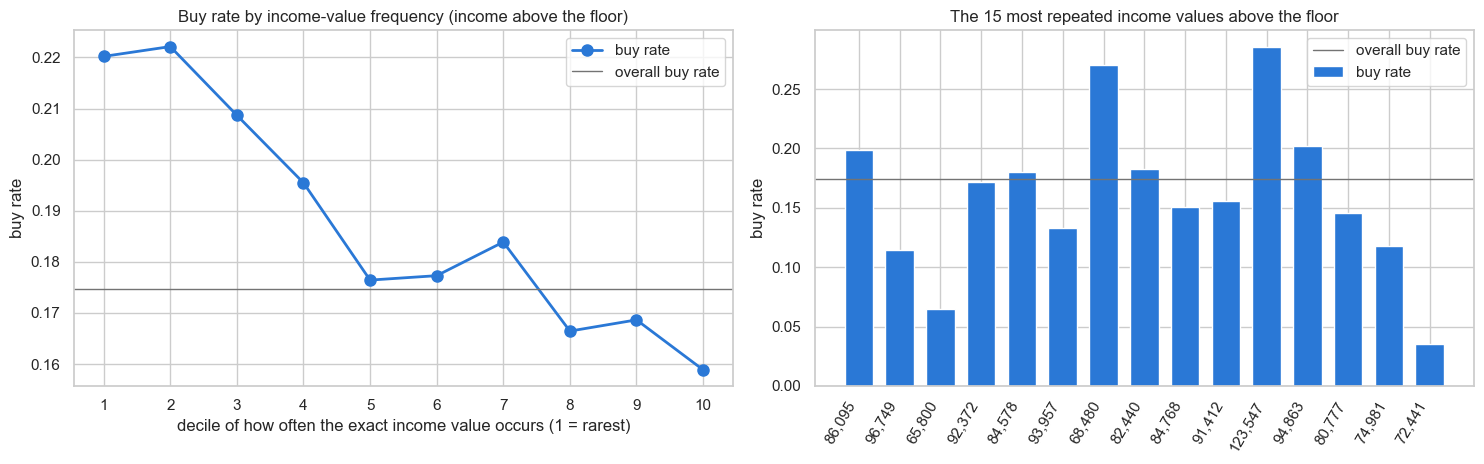

floor value 30,000: 87,881 rows in train + test, buy rate 0.044


,count range,buy rate
1,"(0.999, 56.0]",0.220
2,"(56.0, 91.0]",0.222
3,"(91.0, 124.0]",0.209
4,"(124.0, 155.0]",0.195
5,"(155.0, 185.0]",0.176
6,"(185.0, 216.0]",0.177
7,"(216.0, 254.0]",0.184
8,"(254.0, 317.0]",0.166
9,"(317.0, 523.0]",0.169
10,"(523.0, 1552.0]",0.159


In [15]:
INCOME_COUNTS = pd.concat([train["Annual_Income_USD"], test["Annual_Income_USD"]]).value_counts()

income = pd.DataFrame(
    {"income": train["Annual_Income_USD"], "count": train["Annual_Income_USD"].map(INCOME_COUNTS), "bought": y}
)
above_floor = income[income["income"] > INCOME_FLOOR]
by_count_decile = above_floor.groupby(
    pd.qcut(above_floor["count"], 10, duplicates="drop"), observed=True
)["bought"].mean()
deciles = range(1, len(by_count_decile) + 1)
most_repeated = (
    above_floor.groupby("income")
    .agg(count=("count", "first"), buy_rate=("bought", "mean"))
    .sort_values("count", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].plot(deciles, by_count_decile.values, "o-", color=COLORS[0], lw=2, markersize=8, label="buy rate")
axes[0].axhline(y.mean(), color="0.45", lw=1, label="overall buy rate")
axes[0].set_xticks(deciles)
axes[0].set_xlabel("decile of how often the exact income value occurs (1 = rarest)")
axes[0].set_ylabel("buy rate")
axes[0].set_title("Buy rate by income-value frequency (income above the floor)")
axes[0].legend()

axes[1].bar(range(len(most_repeated)), most_repeated["buy_rate"], color=COLORS[0], width=0.7, label="buy rate")
axes[1].axhline(y.mean(), color="0.45", lw=1, label="overall buy rate")
axes[1].set_xticks(range(len(most_repeated)), [f"{v:,.0f}" for v in most_repeated.index], rotation=60, ha="right")
axes[1].set_ylabel("buy rate")
axes[1].set_title("The 15 most repeated income values above the floor")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"floor value {INCOME_FLOOR:,.0f}: {INCOME_COUNTS[INCOME_FLOOR]:,} rows in train + test, "
      f"buy rate {income.loc[income['income'] == INCOME_FLOOR, 'bought'].mean():.3f}")
pd.DataFrame({"count range": by_count_decile.index.astype(str), "buy rate": by_count_decile.values.round(3)}, index=deciles)

Two features follow from this:

- **`Income_count`** — how often the exact income value occurs in train + test. It uses no labels, so
  computing it on train and test together is safe.
- **`Annual_Income_USD_te`** — target encoding of the exact income value: the smoothed buy rate of
  training rows with that value. It *does* use labels, so it must be fit inside each training fold.
  `FoldTargetEncoder` wraps scikit-learn's `TargetEncoder`, which cross-fits the training rows (a row's
  own label never feeds its own encoding) and encodes validation and test rows from the whole training
  fold. Rare values are shrunk toward the overall rate (`smooth="auto"`).

In [16]:
def add_income_count(df):
    return df.assign(Income_count=df["Annual_Income_USD"].map(INCOME_COUNTS).astype(float))


class FoldTargetEncoder:
    """Target-encode columns with the labels of one training fold only. `smooth` and `suffix` are
    exposed so the same class can produce several encodings of the same columns at once (§6.3)."""

    def __init__(self, cols, smooth="auto", suffix="_te"):
        self.cols = list(cols)
        self.smooth = smooth
        self.suffix = suffix

    def fit(self, X, y):
        self.encoder_ = TargetEncoder(target_type="binary", smooth=self.smooth, cv=5, shuffle=True, random_state=SEED)
        # fit_transform cross-fits: each training row is encoded from the other 4/5 of the fold
        self.train_frame_ = self._attach(X, self.encoder_.fit_transform(X[self.cols], y))
        return self

    def transform(self, X):
        return self._attach(X, self.encoder_.transform(X[self.cols]))

    def _attach(self, X, encoded):
        out = X.copy()
        for i, col in enumerate(self.cols):
            out[f"{col}{self.suffix}"] = encoded[:, i]
        return out


TE_COLS = ["Annual_Income_USD"]


def with_target_encoding(fit_fold_fn, cols=TE_COLS):
    """Wrap a fold-fitting function so the target encoder is fit on the training fold only."""

    def fit_fold(X_trn, y_trn, X_val, y_val):
        encoder = FoldTargetEncoder(cols).fit(X_trn, y_trn)
        predict, best_iter = fit_fold_fn(encoder.train_frame_, y_trn, encoder.transform(X_val), y_val)
        return (lambda d: predict(encoder.transform(d))), best_iter

    return fit_fold


X_fe, X_test_fe = add_income_count(X), add_income_count(X_test)

cross_validate_model("LightGBM + income count", lgbm_fold_factory(), X_fe, X_test_fe)
cross_validate_model("LightGBM + income count + TE", with_target_encoding(lgbm_fold_factory()), X_fe, X_test_fe)
print()
compare("LightGBM", "LightGBM + income count")
compare("LightGBM + income count", "LightGBM + income count + TE");

LightGBM + income count                OOF AUC = 0.94310  (fold std 0.00071)  76.4s
                                       best iterations: [1091, 1037, 970, 633, 1147]


LightGBM + income count + TE           OOF AUC = 0.94555  (fold std 0.00065)  46.5s
                                       best iterations: [601, 430, 559, 434, 451]

LightGBM + income count  vs  LightGBM: +0.00110 ± 0.00015   per fold [0.0013  0.00112 0.00112 0.00088 0.0011 ]
LightGBM + income count + TE  vs  LightGBM + income count: +0.00244 ± 0.00008   per fold [0.00257 0.00238 0.00238 0.00242 0.00247]


In [17]:
# Community idea (see §6 intro): the source notebook target-encodes every column, not just income.
CATEGORICAL_TE_COLS = TE_COLS + CATEGORICAL_COLS

cross_validate_model(
    "LightGBM + income count + TE (+ categoricals)",
    with_target_encoding(lgbm_fold_factory(), cols=CATEGORICAL_TE_COLS),
    X_fe,
    X_test_fe,
)
compare("LightGBM + income count + TE", "LightGBM + income count + TE (+ categoricals)")

LightGBM + income count + TE (+ categoricals) OOF AUC = 0.94552  (fold std 0.00064)  51.0s
                                       best iterations: [476, 582, 636, 381, 503]
LightGBM + income count + TE (+ categoricals)  vs  LightGBM + income count + TE: -0.00003 ± 0.00003   per fold [-3.e-05 -1.e-05 -6.e-05  0.e+00 -4.e-05]


array([-3.35776145e-05, -1.03395499e-05, -6.47863669e-05,  1.09970452e-06,
       -3.52060608e-05])

In [18]:
def add_income_commute_bins(df):
    """Coarser multi-resolution keys for the same generator artifact the income target encoding above
    exploits: rounding to the nearest 100 / 1000 groups rare exact values into bins with more rows each.
    The binning + two-smoothing-level TE idea is from the community (see §6 intro: credited there to
    Markus.JM's CTBoost baseline), adapted here onto our own fold-safe `FoldTargetEncoder`."""
    return df.assign(
        Income_bin100=(df["Annual_Income_USD"] // 100).astype(int).astype(str),
        Income_bin1000=(df["Annual_Income_USD"] // 1000).astype(int).astype(str),
        Commute_int=df["Daily_Commute_km"].astype(int).astype(str),
    )


BIN_COLS = ["Income_bin100", "Income_bin1000", "Commute_int"]


def with_multi_smooth_encoding(fit_fold_fn, cols, smooths=(10.0, 100.0)):
    """Chain one fold-safe `FoldTargetEncoder` per smoothing level onto `cols`, then drop the raw string
    keys — LightGBM can't take them as-is since they're plain strings, not `category` dtype, and they
    exist only to be encoded. Heavier smoothing (e.g. 100) shrinks each bin's encoding toward the global
    rate, regularizing the narrower bins instead of discarding them outright."""

    def fit_fold(X_trn, y_trn, X_val, y_val):
        X_trn_enc, X_val_enc = X_trn, X_val
        encoders = []
        for s in smooths:
            suffix = f"_te{s}" if isinstance(s, str) else f"_te{int(s)}"  # "auto" or a number
            enc = FoldTargetEncoder(cols, smooth=s, suffix=suffix).fit(X_trn_enc, y_trn)
            encoders.append(enc)
            X_trn_enc, X_val_enc = enc.train_frame_, enc.transform(X_val_enc)
        predict, best_iter = fit_fold_fn(X_trn_enc.drop(columns=cols), y_trn, X_val_enc.drop(columns=cols), y_val)

        def predict_chained(d):
            for enc in encoders:
                d = enc.transform(d)
            return predict(d.drop(columns=cols))

        return predict_chained, best_iter

    return fit_fold


def with_target_encoding_and_bins(fit_fold_fn):
    """§6's income TE, chained with the multi-scale bin TE at two extra smoothing levels."""
    return with_target_encoding(with_multi_smooth_encoding(fit_fold_fn, BIN_COLS))


X_bins, X_test_bins = add_income_commute_bins(X_fe), add_income_commute_bins(X_test_fe)

cross_validate_model(
    "LightGBM + income count + TE + multi-scale bins",
    with_target_encoding_and_bins(lgbm_fold_factory()),
    X_bins,
    X_test_bins,
)
compare("LightGBM + income count + TE", "LightGBM + income count + TE + multi-scale bins")

LightGBM + income count + TE + multi-scale bins OOF AUC = 0.94581  (fold std 0.00062)  49.7s
                                       best iterations: [475, 383, 455, 381, 583]
LightGBM + income count + TE + multi-scale bins  vs  LightGBM + income count + TE: +0.00026 ± 0.00005   per fold [0.00027 0.00029 0.00017 0.00029 0.0003 ]


array([0.00027277, 0.00028771, 0.00016549, 0.00028657, 0.00029726])

### Value pools and the wide encoding

Income turned out to be an *identity* as much as a quantity. The check below looks at where the values come
from. If the generator draws each column's values from the original survey's pool, then an exact value — of
any column, not only income — can carry its own label rate. It also tests whether whole survey rows are
copied: a synthetic row is linked to the survey respondent with the same (unique) income, and each other
column's agreement with that respondent is set against chance.

In [19]:
if original is not None:
    pools = pd.DataFrame(
        {
            col: {
                "distinct values (train)": train[col].nunique(),
                "distinct values (survey)": original[col].nunique(),
                "train rows whose value is in the survey": train[col].isin(original[col].dropna()).mean(),
            }
            for col in ["Annual_Income_USD", "Daily_Commute_km"]
        }
    )
    display(pools.round(4))

    # incomes held by exactly one survey respondent link a synthetic row to "its" respondent
    income_owner = original.drop_duplicates("Annual_Income_USD", keep=False).set_index("Annual_Income_USD")
    linked = train[train["Annual_Income_USD"].isin(income_owner.index)]
    owner = income_owner.loc[linked["Annual_Income_USD"]]
    agreement = pd.DataFrame(
        {
            col: {
                "agreement with linked respondent": (linked[col].values == owner[col].values).mean(),
                # two independent draws from the two marginals agree this often
                "agreement by chance": (
                    linked[col].value_counts(normalize=True) * original[col].value_counts(normalize=True)
                ).sum(),
            }
            for col in [c for c in FEATURES if c != "Annual_Income_USD"] + [TARGET]
        }
    ).T
    print(f"train rows linked to a unique survey income: {len(linked):,} ({len(linked) / len(train):.0%})")
    display(agreement.round(3))

,Annual_Income_USD,Daily_Commute_km
distinct values (train),13214.0000,805.0
distinct values (survey),8915.0000,991.0
train rows whose value is in the survey,0.9794,1.0


train rows linked to a unique survey income: 506,588 (76%)


,agreement with linked respondent,agreement by chance
Age,0.024,0.022
Daily_Commute_km,0.020,0.018
Number_of_Cars_Owned,0.366,0.366
Charging_Stations_Near_Home,0.109,0.083
Charging_Stations_Near_Work,0.087,0.063
Environmental_Concern_Level,0.205,0.200
Gender,0.486,0.485
City_Type,0.498,0.378
Current_Car_Type,0.393,0.334
Home_Charging_Possible,0.579,0.545


**Notes (development run).** 97.9% of train incomes and 99.99% of commutes appear verbatim in the 10,000-row
survey — the generator draws values from the survey's pools. It copies rows only *partly*: against the linked
respondent, city type agrees 50% of the time vs 38% by chance, car type and the station counts a few points
above chance, the label 72% vs 70%, and every other column at chance. (Chance computed within income bands is
the same, so this is not the columns' correlation with income.) Development runs also gave LightGBM the linked
respondent's label and how many columns match it: no gain (+0.00000 ± 0.00004), since the income target
encoding already carries that. So the per-value label rates are mostly the synthetic data's own, and target
encoding is the way to read them — for every column, not only income.

The *wide encoding* applies the income treatment to every column (community idea, see §6 intro):
- each of the 13 columns, plus the three income/commute bins, becomes a string *key*;
- each key gets a frequency count over train + test (label-free — `Income_count` generalized);
- each key gets three fold-fitted target encodings, at `smooth` = auto, 10 and 100.

It contains `Income_count` and the income / bin encodings above, so it replaces them; the magic flags stay.
It is tested with the §5 LightGBM parameters, then with the source notebook's LightGBM shape: a low column
sample (0.3), so that no single one of ~80 correlated encodings dominates the trees, with deeper trees and
small leaves. The shape is also tried on the narrow features, to separate what the keys add from what the
parameters add.

In [20]:
WIDE_KEY_COLS = [f"{col}_key" for col in FEATURES] + ["Income_bin100_key", "Income_bin1000_key", "Commute_int_key"]


def add_wide_keys(df):
    """The wide encoding's string keys: every column's exact value, plus the three income/commute bins."""
    keys = {f"{col}_key": df[col].astype(str) for col in FEATURES}
    keys["Income_bin100_key"] = (df["Annual_Income_USD"] // 100).astype(int).astype(str)
    keys["Income_bin1000_key"] = (df["Annual_Income_USD"] // 1000).astype(int).astype(str)
    keys["Commute_int_key"] = df["Daily_Commute_km"].astype(int).astype(str)
    return df.assign(**keys)


KEY_COUNTS = {
    col: values.value_counts()
    for col, values in add_wide_keys(pd.concat([train[FEATURES], test[FEATURES]]))[WIDE_KEY_COLS].items()
}


def wide_frame(df):
    """Tree features + magic flags + keys + each key's frequency over train + test (no labels used)."""
    out = add_wide_keys(add_magic_flags(df))
    return out.assign(
        **{col.replace("_key", "_count"): out[col].map(KEY_COUNTS[col]).astype(float) for col in WIDE_KEY_COLS}
    )


def with_wide_encoding(fit_fold_fn):
    """Three fold-fitted target encodings per key (smooth = auto, 10, 100); the raw keys are dropped."""
    return with_multi_smooth_encoding(fit_fold_fn, WIDE_KEY_COLS, smooths=("auto", 10.0, 100.0))


# The source notebook's LightGBM shape (community idea, see §6 intro), on top of LGB_BASE_PARAMS
WIDE_LGB_PARAMS = dict(
    max_depth=5,
    num_leaves=32,
    min_child_samples=10,
    feature_fraction=0.3,
    bagging_fraction=0.81,
    lambda_l1=0.07,
    lambda_l2=2.0,
)

X_wide, X_test_wide = wide_frame(X), wide_frame(X_test)
print(f"{X_wide.shape[1] + 2 * len(WIDE_KEY_COLS)} model features after encoding ({len(WIDE_KEY_COLS)} keys)")

cross_validate_model("LightGBM + wide encoding", with_wide_encoding(lgbm_fold_factory()), X_wide, X_test_wide)
cross_validate_model(
    "LightGBM + income count + TE + multi-scale bins (wide params)",
    with_target_encoding_and_bins(lgbm_fold_factory(WIDE_LGB_PARAMS)),
    X_bins,
    X_test_bins,
)
cross_validate_model(
    "LightGBM + wide encoding (wide params)", with_wide_encoding(lgbm_fold_factory(WIDE_LGB_PARAMS)), X_wide, X_test_wide
)
print()
compare("LightGBM + income count + TE + multi-scale bins", "LightGBM + wide encoding")
compare("LightGBM + income count + TE + multi-scale bins", "LightGBM + income count + TE + multi-scale bins (wide params)")
compare("LightGBM + wide encoding", "LightGBM + wide encoding (wide params)");

80 model features after encoding (16 keys)


LightGBM + wide encoding               OOF AUC = 0.94588  (fold std 0.00065)  87.6s
                                       best iterations: [224, 327, 404, 235, 309]


LightGBM + income count + TE + multi-scale bins (wide params) OOF AUC = 0.94584  (fold std 0.00065)  53.2s
                                       best iterations: [449, 456, 516, 434, 484]


LightGBM + wide encoding (wide params) OOF AUC = 0.94597  (fold std 0.00061)  82.6s
                                       best iterations: [253, 230, 313, 243, 271]

LightGBM + wide encoding  vs  LightGBM + income count + TE + multi-scale bins: +0.00007 ± 0.00006   per fold [3.0e-05 1.0e-05 7.0e-05 1.5e-04 1.0e-04]
LightGBM + income count + TE + multi-scale bins (wide params)  vs  LightGBM + income count + TE + multi-scale bins: +0.00003 ± 0.00007   per fold [-1.0e-05  7.0e-05  1.1e-04 -7.0e-05  6.0e-05]
LightGBM + wide encoding (wide params)  vs  LightGBM + wide encoding: +0.00008 ± 0.00005   per fold [1.7e-04 9.0e-05 5.0e-05 8.0e-05 3.0e-05]


### More training rows per fold

Every target encoding is a per-value average, and the rarer the value, the noisier the average. With 5 folds
each fold model — and its encoders — sees 80% of the training rows; with 10 folds, 90%. If the encodings are
starved for rows, the same model should score better on 10 folds. The folds differ, so this is a pooled OOF
comparison, not a paired one.

In [21]:
TEN_FOLD_RUN = f"LightGBM + wide encoding (wide params, {FINAL_SPLITS} folds)"
cross_validate_model(
    TEN_FOLD_RUN, with_wide_encoding(lgbm_fold_factory(WIDE_LGB_PARAMS)), X_wide, X_test_wide, split=final_folds
)
gain = results[TEN_FOLD_RUN]["auc"] - results["LightGBM + wide encoding (wide params)"]["auc"]
print(f"{FINAL_SPLITS} folds vs {N_SPLITS} folds, same model and features: {gain:+.5f} pooled OOF AUC")

LightGBM + wide encoding (wide params, 10 folds) OOF AUC = 0.94613  (fold std 0.00080)  160.2s
                                       best iterations: [241, 238, 227, 419, 362, 278, 219, 243, 262, 261]
10 folds vs 5 folds, same model and features: +0.00016 pooled OOF AUC


### Pseudo-labelled target encodings

More rows per fold was the biggest gain in this section, and there are 286,571 more rows in sight: the test
set. Its labels are unknown, but a model can guess them — so a first model, fit without the validation fold,
labels the test rows, and the target encoders are then refit on the training fold **plus** those test rows
carrying the predicted (soft) labels. Every per-value average is then computed from ~54% more rows.

The guesses carry no new label information, so this is smoothing rather than new signal, and the encodings
it produces differ from the ordinary ones — which is what §9 wants from an ensemble member. No validation
label is used at any point: the pseudo-labels come from a model that never saw the fold.

In [22]:
def with_pseudo_label_encoding(fit_fold_fn, test_frame, smooths=("auto", 10.0, 100.0)):
    """Two-stage fold fit: stage 1 labels the test rows, stage 2 encodes with them and fits the model."""

    def fit_fold(X_trn, y_trn, X_val, y_val):
        predict_stage1, _ = with_wide_encoding(fit_fold_fn)(X_trn, y_trn, X_val, y_val)
        pseudo_labels = predict_stage1(test_frame)

        keys = pd.concat([X_trn[WIDE_KEY_COLS], test_frame[WIDE_KEY_COLS]], ignore_index=True)
        target = np.r_[y_trn.astype(float), pseudo_labels]  # soft labels -> a continuous target
        encoders, encoded_trn = [], {}
        for s in smooths:
            suffix = f"_te{s}" if isinstance(s, str) else f"_te{int(s)}"
            enc = TargetEncoder(target_type="continuous", smooth=s, cv=5, shuffle=True, random_state=SEED)
            # cross-fitted, so a training row is never encoded from its own label
            cross_fitted = enc.fit_transform(keys, target)[: len(X_trn)]
            encoders.append((enc, suffix))
            encoded_trn.update({f"{col}{suffix}": cross_fitted[:, i] for i, col in enumerate(WIDE_KEY_COLS)})

        def encode(df):
            out = {}
            for enc, suffix in encoders:
                encoded = enc.transform(df[WIDE_KEY_COLS])
                out.update({f"{col}{suffix}": encoded[:, i] for i, col in enumerate(WIDE_KEY_COLS)})
            return pd.concat([df.drop(columns=WIDE_KEY_COLS).reset_index(drop=True), pd.DataFrame(out)], axis=1)

        X_trn_enc = pd.concat(
            [X_trn.drop(columns=WIDE_KEY_COLS).reset_index(drop=True), pd.DataFrame(encoded_trn)], axis=1
        )
        predict, best_iter = fit_fold_fn(X_trn_enc, y_trn, encode(X_val), y_val)
        return (lambda d: predict(encode(d))), best_iter

    return fit_fold


cross_validate_model(
    "LightGBM + pseudo-labelled TE",
    with_pseudo_label_encoding(lgbm_fold_factory(WIDE_LGB_PARAMS), X_test_wide),
    X_wide,
    X_test_wide,
)
compare("LightGBM + wide encoding (wide params)", "LightGBM + pseudo-labelled TE");

LightGBM + pseudo-labelled TE          OOF AUC = 0.94606  (fold std 0.00060)  165.2s
                                       best iterations: [366, 234, 297, 212, 291]
LightGBM + pseudo-labelled TE  vs  LightGBM + wide encoding (wide params): +0.00010 ± 0.00003   per fold [1.2e-04 1.2e-04 1.1e-04 4.0e-05 1.1e-04]


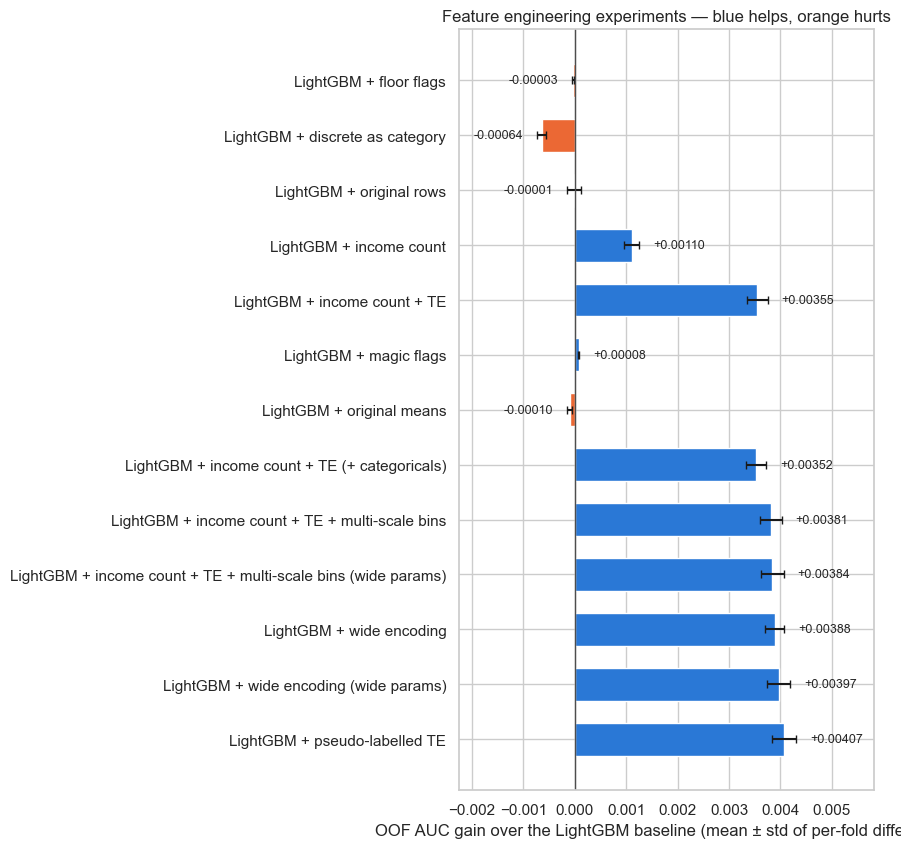

,gain,std
experiment,,
LightGBM + floor flags,-0.00003,0.00002
LightGBM + discrete as category,-0.00064,0.00009
LightGBM + original rows,-0.00001,0.00014
LightGBM + income count,0.00110,0.00015
LightGBM + income count + TE,0.00355,0.00021
LightGBM + magic flags,0.00008,0.00001
LightGBM + original means,-0.00010,0.00005
LightGBM + income count + TE (+ categoricals),0.00352,0.00020
LightGBM + income count + TE + multi-scale bins,0.00381,0.00022


In [23]:
fe_runs = [
    name
    for name in [
        "LightGBM + floor flags",
        "LightGBM + discrete as category",
        "LightGBM + original rows",
        "LightGBM + income count",
        "LightGBM + income count + TE",
        "LightGBM + magic flags",
        "LightGBM + original means",
        "LightGBM + income count + TE (+ categoricals)",
        "LightGBM + income count + TE + multi-scale bins",
        "LightGBM + income count + TE + multi-scale bins (wide params)",
        "LightGBM + wide encoding",
        "LightGBM + wide encoding (wide params)",
        "LightGBM + pseudo-labelled TE",
    ]
    if name in results
]
fe_deltas = pd.DataFrame(
    [
        {"experiment": name, "gain": d.mean(), "std": d.std(ddof=1)}
        for name in fe_runs
        for d in [np.array(results[name]["fold_aucs"]) - np.array(results["LightGBM"]["fold_aucs"])]
    ]
).set_index("experiment")

fig, ax = plt.subplots(figsize=(9, 0.55 * len(fe_deltas) + 1.5))
bar_colors = [COLORS[0] if g > 0 else COLORS[1] for g in fe_deltas["gain"]]
ax.barh(fe_deltas.index, fe_deltas["gain"], xerr=fe_deltas["std"], color=bar_colors, height=0.6, capsize=3)
ax.axvline(0, color="0.3", lw=1)
lo = min(0.0, (fe_deltas["gain"] - fe_deltas["std"]).min())
hi = max(0.0, (fe_deltas["gain"] + fe_deltas["std"]).max())
width = hi - lo
for i, (g, s) in enumerate(zip(fe_deltas["gain"], fe_deltas["std"])):
    ax.annotate(
        f"{g:+.5f}", (g + np.sign(g) * s, i), xytext=(10 if g >= 0 else -10, 0), textcoords="offset points",
        ha="left" if g >= 0 else "right", va="center", fontsize=9,
    )
ax.set_xlim(lo - (0.3 * width if lo < 0 else 0.05 * width), hi + 0.3 * width)
ax.invert_yaxis()
ax.set_xlabel("OOF AUC gain over the LightGBM baseline (mean ± std of per-fold differences)")
ax.set_title("Feature engineering experiments — blue helps, orange hurts")
plt.tight_layout()
plt.show()

fe_deltas.round(5)

**Notes (development runs)** — paired gains over the LightGBM baseline (0.94200):

| Experiment | Gain | Verdict |
|---|---|---|
| Floor flags | −0.00003 | a split at the minimum already isolates the floor |
| Discrete numerics as categories | ≈ −0.0006 | categorical splits overfit |
| Original survey rows | −0.00001 | different relationships (§1) — no help |
| Income count | **+0.00110 ± 0.00015** | kept |
| Income count + income target encoding | **+0.00355 ± 0.00021** (AUC 0.94555) | kept |
| Magic threshold flags (millionaire cliff, dead zone, env-hater) | **+0.00008 ± 0.00001** | small but positive on every fold — kept |
| Original survey means (per-level buy rate as a feature) | −0.00010 ± 0.00005 | confirms §1: the survey's relationships are too different to transfer — dropped |
| Target encoding the categorical columns too | −0.00003 ± 0.00003 | within noise — LightGBM already splits low-cardinality categoricals natively — dropped |
| + Multi-scale income/commute bins, TE'd at smooth=10 and smooth=100 | **+0.00026 ± 0.00005** (AUC 0.94581, on top of income count + TE) | kept — the single largest gain since the income target encoding itself |
| The wide LightGBM shape on those same features (no new keys) | +0.00003 ± 0.00007 | the tree shape alone is not the gain |
| + Wide encoding: every column as a key | **+0.00007 ± 0.00006** (AUC 0.94588) | small but positive on every fold — kept |
| + Wide encoding *and* the wide LightGBM shape | **+0.00008 ± 0.00005** on top of that (AUC 0.94597) | kept — the keys need the low column sample to pay off |
| Same model and features on 10 folds instead of 5 | **+0.00016** pooled (AUC 0.94613) | kept: §8 fits the final models on `final_folds` |
| + Pseudo-labelled test rows in the encoders | **+0.00010 ± 0.00003** (AUC 0.94606) | kept — better on every fold, and §9 gets another +0.00006 out of it |

The target encoding adds **+0.0024** on top of the count, higher on every fold. Income *value identity* is
the big win: the generator reuses specific income values, and which label goes with a value carries over
from training rows to validation rows. It's a property of how this synthetic data was made rather than of
real buyers, but it's legitimate here — neither feature sees validation labels.

The multi-scale bins extend the same idea to coarser resolutions (÷100, ÷1000) with heavier smoothing,
picking up rows the exact-value encoding is too sparse to help.

The wide encoding then applies the same treatment to every column. Its two halves are each small but
consistent: the extra keys are worth +0.00007 ± 0.00006 over the bins, and the LightGBM shape that goes with
them another +0.00008 ± 0.00005 — while that shape on the narrow features alone is worth only
+0.00003 ± 0.00007. The keys and the low column sample only pay off together.

Ten folds instead of five is worth +0.00016 more — on its own the largest step in this section since the
multi-scale bins, and it needs no new feature at all: the per-value encodings really were starved for rows,
and 90% of the data estimates them better than 80%. §8 fits the final models that way, and their test
predictions get the same benefit.

§7–8 therefore tune and fit on `X_wide`/`X_test_wide` (`X_final`/`X_test_final`) through
`with_wide_encoding`, so `STUDY_VERSION` was bumped to `"wide_v1"` — the old `best_params.json`/Optuna trials
were tuned on a different feature set and don't apply here.

Also tried during development and left out: counts for every numeric column (−0.0002 vs the income count
alone), target-encoding commute as well (+0.00006), the survey's buy rate per income value (+0.00002 once
the target encoding is in), income crossed with subsidy or concern level (−0.00016), and target-encoded
pairs of the original features (−0.0005). On top of the wide encoding, each of these landed within ±0.00002
of it: the source notebook's digit features, `max_bin=1024`, a 20-fold inner CV for the target encoders, and
giving LightGBM the linked survey respondent's label and match count (+0.00000 ± 0.00004) — the income target
encoding already carries what the partial row-copying leaks. The encoders themselves are also at their
ceiling: averaging them over three cross-fitting seeds cost −0.00004, two extra smoothing levels (1 and
1000) −0.00002, and a 10-fold inner cross-fit instead of 5 exactly nothing.

## 7. Hyperparameter tuning — Optuna

Selected features: the §6 wide encoding — the 13 raw columns, the magic flags, and for each of the 16 keys a
frequency count plus three fold-fitted target encodings (80 columns). §6 found that the column sample matters
with this many correlated encodings, so the LightGBM and XGBoost search ranges for it now reach down to 0.1,
and CatBoost gets its equivalent, `rsm`.

All three boosters are tuned with Optuna's TPE sampler. To keep a trial cheap:
- it scores a single holdout split — the first CV fold — whose target encoder is fit once, up front;
- it uses a fixed learning rate of 0.1 with early stopping. Tree shape and regularization carry over to a
  lower learning rate, which §8 uses for the final models.

Trials are stored in `artifacts/optuna.db`: re-running this section resumes the studies instead of
repeating them. Change `STUDY_VERSION` after changing the feature set so old trials aren't reused.

In [24]:
STUDY_VERSION = "wide_v1"  # bumped: §7–8 now use the §6 wide encoding
OPTUNA_STORAGE = f"sqlite:///{ARTIFACTS / 'optuna.db'}"
BEST_PARAMS_PATH = ARTIFACTS / "best_params.json"
TUNING_LR = 0.1

X_final, X_test_final = X_wide, X_test_wide

hold_trn, hold_val = folds[0]
y_h_trn, y_h_val = y[hold_trn], y[hold_val]

_captured = {}


def _capture_fit_fold(X_trn, y_trn, X_val, y_val):
    """Stand-in for a real fit: just records the encoded frames so tuning reuses the exact same
    encoding chain (the wide encoding) as the final models, instead of a second copy."""
    _captured["X_trn"], _captured["X_val"] = X_trn, X_val
    return (lambda d: d), None


with_wide_encoding(_capture_fit_fold)(X_final.iloc[hold_trn], y_h_trn, X_final.iloc[hold_val], y_h_val)
H_trn, H_val = _captured["X_trn"], _captured["X_val"]
H_trn_cb, H_val_cb = catboost_frame(H_trn), catboost_frame(H_val)


def lgbm_objective(trial):
    params = dict(
        num_leaves=trial.suggest_int("num_leaves", 4, 64, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 1000, log=True),
        feature_fraction=trial.suggest_float("feature_fraction", 0.1, 0.8),
        bagging_fraction=trial.suggest_float("bagging_fraction", 0.5, 1.0),
        lambda_l1=trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
        lambda_l2=trial.suggest_float("lambda_l2", 1e-3, 30.0, log=True),
    )
    model = lgb.LGBMClassifier(**{**LGB_BASE_PARAMS, **params, "learning_rate": TUNING_LR})
    lgb_fit(model, H_trn, y_h_trn, H_val, y_h_val, stopping_rounds=100)
    return roc_auc_score(y_h_val, model.predict_proba(H_val)[:, 1])


def xgb_objective(trial):
    params = dict(
        max_depth=trial.suggest_int("max_depth", 2, 8),
        min_child_weight=trial.suggest_float("min_child_weight", 1.0, 200.0, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.1, 0.8),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 50.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
    )
    model = xgb.XGBClassifier(
        **{**XGB_BASE_PARAMS, **params, "n_estimators": 4000, "learning_rate": TUNING_LR},
        early_stopping_rounds=100,
    )
    model.fit(H_trn, y_h_trn, eval_set=[(H_val, y_h_val)], verbose=False)
    return roc_auc_score(y_h_val, model.predict_proba(H_val)[:, 1])


def catboost_objective(trial):
    params = dict(
        depth=trial.suggest_int("depth", 3, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 50.0, log=True),
        random_strength=trial.suggest_float("random_strength", 0.1, 10.0, log=True),
        # CatBoost's default MVS bootstrap uses `subsample`; `bagging_temperature` would be silently ignored
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        rsm=trial.suggest_float("rsm", 0.1, 0.8),  # CatBoost's column sample
    )
    model = CatBoostClassifier(
        **{**CATBOOST_BASE_PARAMS, **params, "iterations": 4000, "learning_rate": TUNING_LR},
        early_stopping_rounds=100,
    )
    model.fit(H_trn_cb, y_h_trn, eval_set=(H_val_cb, y_h_val))
    return roc_auc_score(y_h_val, model.predict_proba(H_val_cb)[:, 1])


def completed_trials(study):
    # Only COMPLETE trials carry a value; FAIL / RUNNING trials (e.g. from an interrupted run) do not.
    return [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]


def run_study(model_name, objective, n_trials):
    study = optuna.create_study(
        study_name=f"{model_name}_{STUDY_VERSION}",
        storage=OPTUNA_STORAGE,
        load_if_exists=True,
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    start = time.time()
    # Catching KeyboardInterrupt keeps the finished trials usable if the cell is stopped early.
    try:
        remaining = n_trials - len(completed_trials(study))
        if remaining > 0:
            study.optimize(objective, n_trials=remaining)
    except KeyboardInterrupt:
        print("interrupted — keeping the trials that finished")
    if not completed_trials(study):
        raise RuntimeError(f"No {model_name} trial finished — re-run this cell, or lower N_TRIALS.")
    print(
        f"{model_name:9s} {len(completed_trials(study))} trials ({time.time() - start:.0f}s this run)"
        f"  best holdout AUC {study.best_value:.5f}"
    )
    return study

In [25]:
if RUN_TUNING:
    studies = {
        "lightgbm": run_study("lightgbm", lgbm_objective, N_TRIALS["lightgbm"]),
        "xgboost": run_study("xgboost", xgb_objective, N_TRIALS["xgboost"]),
        "catboost": run_study("catboost", catboost_objective, N_TRIALS["catboost"]),
    }
    best_params = {name: study.best_params for name, study in studies.items()}
    BEST_PARAMS_PATH.write_text(json.dumps(best_params, indent=2))
else:
    studies = {}
    best_params = json.loads(BEST_PARAMS_PATH.read_text())

print(json.dumps(best_params, indent=2))

lightgbm  30 trials (0s this run)  best holdout AUC 0.94515
xgboost   20 trials (0s this run)  best holdout AUC 0.94512
catboost  10 trials (0s this run)  best holdout AUC 0.94521
{
  "lightgbm": {
    "num_leaves": 12,
    "max_depth": 2,
    "min_child_samples": 139,
    "feature_fraction": 0.2605408504697717,
    "bagging_fraction": 0.7752847229001598,
    "lambda_l1": 0.010345166060631256,
    "lambda_l2": 0.06966740987206997
  },
  "xgboost": {
    "max_depth": 3,
    "min_child_weight": 1.060053596280153,
    "subsample": 0.9559213589718202,
    "colsample_bytree": 0.3657229703941564,
    "reg_lambda": 1.0257469228425895,
    "reg_alpha": 0.6146439247862415
  },
  "catboost": {
    "depth": 4,
    "l2_leaf_reg": 3.2877474139911183,
    "random_strength": 1.120760621186057,
    "subsample": 0.7159725093210578,
    "rsm": 0.30386039813862936
  }
}


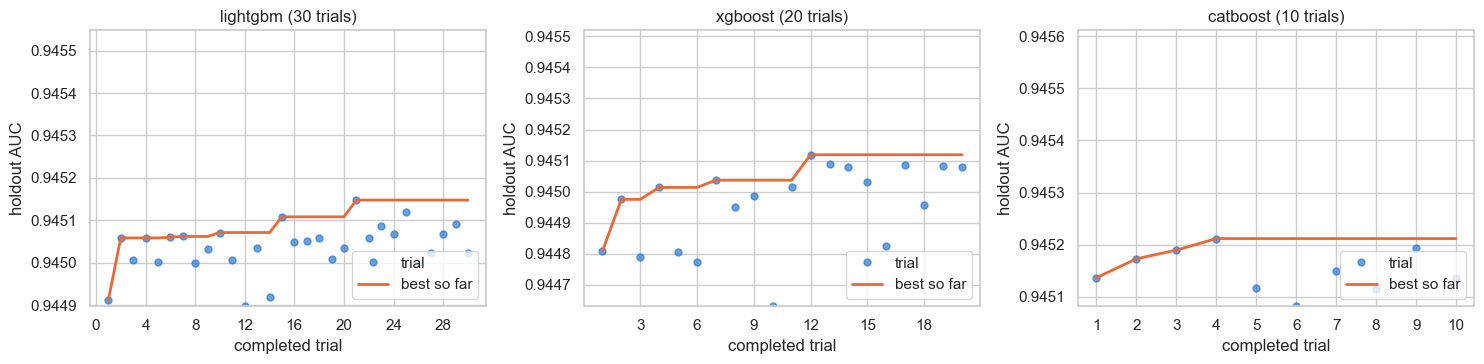

In [26]:
if studies:
    fig, axes = plt.subplots(1, len(studies), figsize=(15, 3.8))
    for ax, (name, study) in zip(axes, studies.items()):
        values = [t.value for t in completed_trials(study)]
        trial_nums = range(1, len(values) + 1)
        ax.plot(trial_nums, values, "o", color=COLORS[0], markersize=5, alpha=0.7, label="trial")
        ax.plot(trial_nums, np.maximum.accumulate(values), color=COLORS[1], lw=2, label="best so far")
        ax.set_ylim(max(min(values), max(values) - 0.003), max(values) + 0.0004)
        ax.set_title(f"{name} ({len(values)} trials)")
        ax.set_xlabel("completed trial")
        ax.set_ylabel("holdout AUC")
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

**What to look for.** §6 found that a low column sample is what lets the boosters use ~80 correlated
encodings, so expect `feature_fraction` / `colsample_bytree` / `rsm` near the low end of their ranges; tree
depth matters less, since §5 found the signal almost additive. Holdout AUC at learning rate 0.1 only ranks trials; §8 re-scores the winners with
5-fold CV at a lower rate. If a best-so-far curve is still climbing at its last trial, raise that model's
`N_TRIALS` and re-run — finished trials are reused.

## 8. Final models

The tuned parameters at a lower learning rate (with more patience for early stopping), on the wide encoding
and the 10 `final_folds` — §6 showed the extra rows per fold are worth it. Every fold fits its own target
encoders. Each booster is fit once per seed in `FINAL_SEEDS` and the fits are averaged. The linear model keeps
its §4 features plus the two income features, as splines.

Two more members round out the blend. One is §6's pseudo-labelled encoding, whose errors differ from the
others' because its encoders were fit on different rows. The other is a booster on the *narrow* §6 features (income count, income target encoding, multi-scale bins)
with the parameters tuned for them in the previous version of this notebook. Alone it is weaker than the
wide models, but its errors differ from theirs — in development it earned a share of every fitted blend.

In [27]:
FINAL_LR = {"lightgbm": 0.03, "xgboost": 0.03, "catboost": 0.06}


def seed_averaged(make_fit_fold, seeds=FINAL_SEEDS):
    """Fit one model per seed on the same fold and average their predictions.

    `make_fit_fold(seed)` returns a fold-fitting function. With a single seed this is a plain fit.
    """

    def fit_fold(X_trn, y_trn, X_val, y_val):
        fits = [make_fit_fold(seed)(X_trn, y_trn, X_val, y_val) for seed in seeds]
        best_iter = int(np.mean([best for _, best in fits]))
        return (lambda d: np.mean([predict(d) for predict, _ in fits], axis=0)), best_iter

    return fit_fold


cross_validate_model(
    "LightGBM (tuned)",
    with_wide_encoding(
        seed_averaged(
            lambda seed: lgbm_fold_factory(
                {
                    **best_params["lightgbm"],
                    "learning_rate": FINAL_LR["lightgbm"],
                    "n_estimators": 20000,
                    "random_state": seed,
                },
                stopping_rounds=300,
            )
        )
    ),
    X_final,
    X_test_final,
    save=True,
    split=final_folds,
);

LightGBM (tuned)                       OOF AUC = 0.94617  (fold std 0.00080)  507.0s
                                       best iterations: [3053, 4166, 3662, 4067, 4149, 3013, 2901, 4165, 2709, 3058]


In [28]:
cross_validate_model(
    "XGBoost (tuned)",
    with_wide_encoding(
        seed_averaged(
            lambda seed: xgb_fold_factory(
                {
                    **best_params["xgboost"],
                    "learning_rate": FINAL_LR["xgboost"],
                    "n_estimators": 20000,
                    "random_state": seed,
                },
                stopping_rounds=300,
            )
        )
    ),
    X_final,
    X_test_final,
    save=True,
    split=final_folds,
);

XGBoost (tuned)                        OOF AUC = 0.94621  (fold std 0.00080)  616.3s
                                       best iterations: [2066, 1869, 2091, 2505, 2801, 1688, 1756, 2158, 2303, 2470]


In [29]:
cross_validate_model(
    "CatBoost (tuned)",
    with_wide_encoding(
        seed_averaged(
            lambda seed: catboost_fold_factory(
                {
                    **best_params["catboost"],
                    "learning_rate": FINAL_LR["catboost"],
                    "iterations": 20000,
                    "random_seed": seed,
                },
                stopping_rounds=300,
            )
        )
    ),
    X_final,
    X_test_final,
    save=True,
    split=final_folds,
);

CatBoost (tuned)                       OOF AUC = 0.94620  (fold std 0.00079)  609.7s
                                       best iterations: [661, 899, 1446, 1320, 1870, 1012, 1218, 812, 1392, 1013]


In [30]:
# Tuned for the narrow features by the previous version of §7 (Optuna study "catboost_income_te_bins_v1")
NARROW_CATBOOST_PARAMS = dict(depth=5, l2_leaf_reg=41.23, random_strength=2.91, subsample=0.799)
X_narrow = add_income_commute_bins(add_magic_flags(X_fe))
X_test_narrow = add_income_commute_bins(add_magic_flags(X_test_fe))

cross_validate_model(
    "CatBoost (narrow features)",
    with_target_encoding_and_bins(
        seed_averaged(
            lambda seed: catboost_fold_factory(
                {
                    **NARROW_CATBOOST_PARAMS,
                    "learning_rate": FINAL_LR["catboost"],
                    "iterations": 20000,
                    "random_seed": seed,
                },
                stopping_rounds=300,
            )
        )
    ),
    X_narrow,
    X_test_narrow,
    save=True,
    split=final_folds,
);

CatBoost (narrow features)             OOF AUC = 0.94609  (fold std 0.00083)  481.9s
                                       best iterations: [960, 989, 1123, 1824, 1073, 761, 756, 1157, 1023, 978]


In [31]:
# §6's pseudo-labelled encodings. Two fits per fold, so this member runs at the higher of the final
# learning rates; in development 0.03 and 0.05 scored the same here to within 0.00003.
cross_validate_model(
    "LightGBM (pseudo-labelled TE)",
    with_pseudo_label_encoding(
        seed_averaged(
            lambda seed: lgbm_fold_factory(
                {**best_params["lightgbm"], "learning_rate": 0.05, "n_estimators": 20000, "random_state": seed},
                stopping_rounds=300,
            )
        ),
        X_test_final,
    ),
    X_final,
    X_test_final,
    save=True,
    split=final_folds,
);

LightGBM (pseudo-labelled TE)          OOF AUC = 0.94621  (fold std 0.00080)  848.9s
                                       best iterations: [2327, 2443, 2160, 2340, 3125, 2062, 1685, 2645, 2188, 1477]


In [32]:
X_lr_fe, X_test_lr_fe = add_income_count(X_lr), add_income_count(X_test_lr)

cross_validate_model(
    "LogReg (EDA + income)",
    with_target_encoding(sklearn_fold_factory(lambda: lr_eda(income_features=True))),
    X_lr_fe,
    X_test_lr_fe,
    save=True,
    split=final_folds,
)
print()
gain = results["LogReg (EDA + income)"]["auc"] - results["LogReg (EDA splines)"]["auc"]
print(f"LogReg (EDA + income)  vs  LogReg (EDA splines): {gain:+.5f} pooled OOF AUC ({FINAL_SPLITS} vs {N_SPLITS} folds)")
compare(TEN_FOLD_RUN, "LightGBM (tuned)");

LogReg (EDA + income)                  OOF AUC = 0.94432  (fold std 0.00088)  49.6s

LogReg (EDA + income)  vs  LogReg (EDA splines): +0.00503 pooled OOF AUC (10 vs 5 folds)
LightGBM (tuned)  vs  LightGBM + wide encoding (wide params, 10 folds): +0.00004 ± 0.00006   per fold [ 3.0e-05  6.0e-05  7.0e-05  0.0e+00  1.0e-04  3.0e-05 -3.0e-05 -6.0e-05
  1.3e-04  6.0e-05]


**What to expect.** In development, the same three boosters on the wide encoding at learning rate 0.05 scored
0.9461–0.9462 on 10 folds (vs 0.9460 on 5 folds), and the tuned versions at the lower learning rates here
should land at or a little above that. The last `compare` line shows what tuning plus the lower learning rate
added on top of §6's 10-fold LightGBM.

Two ways of using *more* data were tested during development and rejected. **20 folds** instead of 10 scored
+0.00014 over 5 folds where 10 folds already scored +0.00016 — the gain saturates once a fold model sees 90%
of the rows, so the second doubling buys nothing. A **full-data refit** — one model trained on 100% of the
rows with the iteration count fixed at 1.1x the folds' average, which is how many solutions produce their
test predictions — was compared against fold averaging on three held-out folds and came out level
(−0.00000 ± 0.00005; +0.00002 ± 0.00007 when averaged over three seeds). The extra fifth of the data is
worth about as much as the ensemble of fold models it replaces, so §8 keeps the fold averaging, which also
keeps an honest OOF estimate. Re-scoring Optuna's top five trials on the full 5-fold CV (its holdout AUC
noise is larger than the spread between good trials) confirmed the trial §7 picked was also the best of
them, so the single-holdout selection is good enough here.

## 9. Ensemble

The final models are built differently — three boosting libraries that grow trees in different ways,
plus a spline logistic regression, a booster on different features and one on differently fitted encodings
— but all are scored on the same 10 folds, so their OOF predictions can be
blended and every blend evaluated fairly.

Blends work on **log-odds**, the scale these models natively produce. There, a move from 0.1% to 1% counts
about as much as one from 50% to 90%; averaging raw probabilities would let the second swamp the first, and
most rows sit at low probabilities.

| Blending rule | Weights | Room to overfit |
|---|---|---|
| **Mean log-odds of the three boosters** | equal and fixed | none |
| **Hill climbing** (Caruana et al., 2004) | greedy selection *with replacement*: start from the best single model, keep adding whichever member most improves AUC; weights are the selection counts, so non-negative and summing to 1 | a little |
| **Logistic-regression stacker** | one free coefficient per member, plus an intercept that also recalibrates the output | the most |

The last two learn from the OOF predictions, so scoring them on those same predictions would flatter them.
All blends are therefore evaluated **nested**: weights are fit on nine folds' OOF predictions and scored on
the tenth. Only the weights applied to the test set are fit on all ten folds.

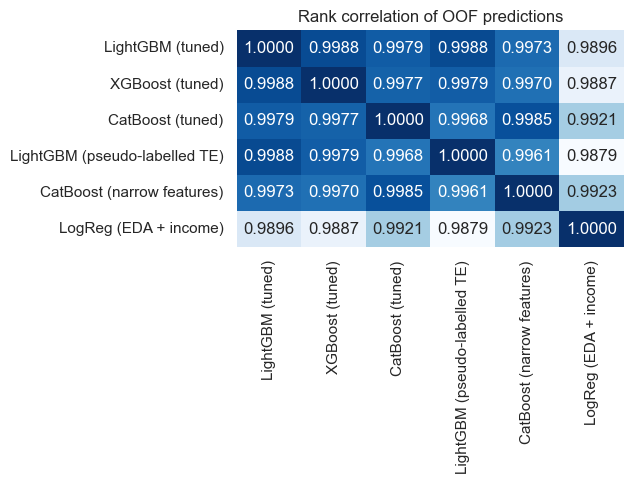

In [33]:
BOOSTERS = ["LightGBM (tuned)", "XGBoost (tuned)", "CatBoost (tuned)"]
ENSEMBLE_MEMBERS = BOOSTERS + [
    "LightGBM (pseudo-labelled TE)",
    "CatBoost (narrow features)",
    "LogReg (EDA + income)",
]

Z_oof = pd.DataFrame({name: to_logit(results[name]["oof"]) for name in ENSEMBLE_MEMBERS})
Z_test = pd.DataFrame({name: to_logit(results[name]["test_pred"]) for name in ENSEMBLE_MEMBERS})

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(Z_oof.corr(method="spearman"), annot=True, fmt=".4f", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Rank correlation of OOF predictions")
plt.tight_layout()
plt.show()

In [34]:
class MeanLogOdds:
    """Equal-weight mean of the chosen members' log-odds; nothing is learned from the labels."""

    def __init__(self, members):
        self.members = members

    def fit(self, Z, y):
        self.weights_ = pd.Series(
            [1 / len(self.members) if col in self.members else 0.0 for col in Z.columns], index=Z.columns
        )
        return self

    def predict(self, Z):
        return expit(Z.values @ self.weights_.values)


class HillClimbing:
    """Greedy ensemble selection with replacement (Caruana et al., 2004), maximizing AUC.

    Starts from the best single member, then repeatedly adds the member whose extra copy most improves
    the blend's AUC, until the gain drops below `tol` or `max_steps` selections are made. Weights are the
    selection counts, normalized to sum to 1.
    """

    def __init__(self, max_steps=25, tol=1e-6):
        self.max_steps = max_steps
        self.tol = tol

    def fit(self, Z, y):
        values = Z.values
        counts = np.zeros(values.shape[1])
        single_aucs = [roc_auc_score(y, values[:, j]) for j in range(values.shape[1])]
        first = int(np.argmax(single_aucs))
        counts[first] = 1
        blend_sum, blend_auc = values[:, first].copy(), single_aucs[first]
        for _ in range(self.max_steps - 1):
            # a sum of log-odds ranks rows exactly like their mean, so AUC can be scored on the sum
            trial_aucs = [roc_auc_score(y, blend_sum + values[:, j]) for j in range(values.shape[1])]
            j = int(np.argmax(trial_aucs))
            if trial_aucs[j] - blend_auc < self.tol:
                break
            counts[j] += 1
            blend_sum += values[:, j]
            blend_auc = trial_aucs[j]
        self.weights_ = pd.Series(counts / counts.sum(), index=Z.columns)
        return self

    def predict(self, Z):
        return expit(Z.values @ self.weights_.values)


class LogisticStacker:
    """Logistic regression on the members' log-odds; the intercept also recalibrates the blend."""

    def fit(self, Z, y):
        self.model_ = LogisticRegression(max_iter=1000).fit(Z.values, y)
        self.weights_ = pd.Series(self.model_.coef_[0], index=Z.columns)
        return self

    def predict(self, Z):
        return self.model_.predict_proba(Z.values)[:, 1]


BLENDS = {
    "Blend: mean log-odds (boosters)": lambda: MeanLogOdds(BOOSTERS),
    "Blend: hill climbing": HillClimbing,
    "Blend: LR stacker": LogisticStacker,
}

Blend: mean log-odds (boosters)        OOF AUC = 0.94626  (fold std 0.00080)  0s


Blend: hill climbing                   OOF AUC = 0.94634  (fold std 0.00080)  36s


Blend: LR stacker                      OOF AUC = 0.94634  (fold std 0.00080)  5s

best single model: LightGBM (pseudo-labelled TE)
Blend: mean log-odds (boosters)  vs  LightGBM (pseudo-labelled TE): +0.00005 ± 0.00008   per fold [-4.0e-05  4.0e-05  4.0e-05  1.6e-04 -0.0e+00  1.3e-04  8.0e-05 -1.2e-04
  9.0e-05  1.1e-04]
Blend: hill climbing  vs  LightGBM (pseudo-labelled TE): +0.00013 ± 0.00006   per fold [7.0e-05 1.2e-04 1.4e-04 2.3e-04 8.0e-05 1.8e-04 1.5e-04 3.0e-05 1.8e-04
 1.3e-04]
Blend: LR stacker  vs  LightGBM (pseudo-labelled TE): +0.00013 ± 0.00005   per fold [7.0e-05 1.2e-04 1.5e-04 2.2e-04 9.0e-05 1.7e-04 1.6e-04 4.0e-05 1.8e-04
 1.2e-04]


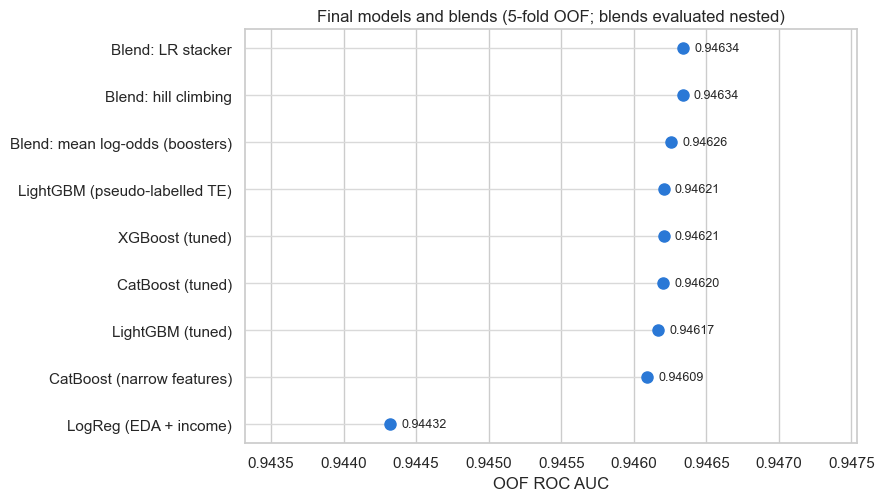

,Blend: mean log-odds (boosters),Blend: hill climbing,Blend: LR stacker
member,,,
LightGBM (tuned),0.333,0.0,-0.237
XGBoost (tuned),0.333,0.2,0.224
CatBoost (tuned),0.333,0.2,0.305
LightGBM (pseudo-labelled TE),0.000,0.4,0.457
CatBoost (narrow features),0.000,0.2,0.293
LogReg (EDA + income),0.000,0.0,-0.041


In [35]:
blend_weights = {}
for name, make_blend in BLENDS.items():
    start = time.time()
    oof = np.zeros(len(y))
    for trn_idx, val_idx in final_folds:
        # nested: the weights that score this fold were fit without it
        fold_blend = make_blend().fit(Z_oof.iloc[trn_idx], y[trn_idx])
        oof[val_idx] = fold_blend.predict(Z_oof.iloc[val_idx])
    full_blend = make_blend().fit(Z_oof, y)  # weights for the test set use all ten folds
    blend_weights[name] = full_blend.weights_
    r = store_result(name, oof, full_blend.predict(Z_test), seconds=time.time() - start, save=True, split=final_folds)
    print(f"{name:38s} OOF AUC = {r['auc']:.5f}  (fold std {np.std(r['fold_aucs']):.5f})  {r['seconds']:.0f}s")

FINAL_CANDIDATES = ENSEMBLE_MEMBERS + list(BLENDS)
best_single = max(ENSEMBLE_MEMBERS, key=lambda name: results[name]["auc"])
print(f"\nbest single model: {best_single}")
for name in BLENDS:
    compare(best_single, name)

plot_auc(FINAL_CANDIDATES, "Final models and blends (5-fold OOF; blends evaluated nested)")
pd.DataFrame(blend_weights).round(3).rename_axis("member")

**What to expect.** The members are highly correlated (see the heatmap), so blends gain little: in
development, blends of the wide boosters beat the best of them by less than +0.0001, and the pseudo-labelled
member — the least correlated booster of the set — added another +0.00006 on top of that (0.94628 with five
members, 0.94634 with six).

The two fitted rules finish in a dead heat (0.946339 vs 0.946338), so §12's pick between them is arbitrary.
They are not equally safe, though: the stacker reaches its score partly through a *negative* weight on one
booster, which cancels correlated errors but extrapolates badly if the test set drifts, while hill climbing
is restricted to non-negative weights summing to 1. §2's adversarial AUC of 0.4998 says there is no drift
here, so either is defensible; on a shifted test set, prefer the hill-climbing predictions.

Diversity was easier to imagine than to find. A LightGBM with DART boosting (0.94574), an XGBoost pairwise
ranker and ExtraTrees on the same encodings all scored well below the members here and took no weight from
the hill climber, and a neural network (0.94535) did the same in the previous version. Nor does a cleverer
blender help: a LightGBM stacker on the members' log-odds scored 0.94620 nested, and one that also sees the
row's subsidy, income and commute — so it could weight members differently per row — 0.94619, both below the
linear stacker's 0.94628. The signal is additive (§5), and so is the best way to combine models of it. The linear model at equal
weight makes a blend worse, which is why the no-fit rule uses the wide boosters only, and the fitted rules
decide how much of the other members to use. A fitted blend is
only worth submitting if it beats the best single model in the nested evaluation; §12 picks by exactly that
score. In the weights table, the stacker's coefficients are raw log-odds weights and needn't sum to 1: a sum
above 1 means it also sharpens the blend, which changes calibration but not AUC.

## 10. Interpretation — SHAP

SHAP values come from LightGBM's built-in `pred_contrib` (no extra package), for the tuned LightGBM refit
on the §7 holdout split. Each value is one feature's contribution to one prediction in log-odds, so the
plots show *how* the model uses each feature — and whether that matches the EDA.

With the wide encoding, each original column feeds several model features (the raw value, a frequency
count, three target encodings, and for income also bins and flags). SHAP values add up, so the plots sum
them per **source column**: the total effect of income, of subsidy, and so on.

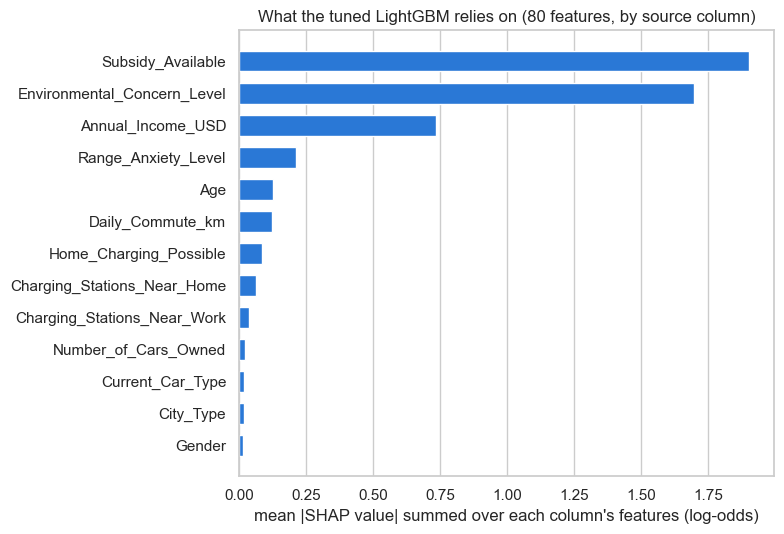

In [36]:
explain_model = lgb_fit(
    lgb.LGBMClassifier(
        **{**LGB_BASE_PARAMS, **best_params["lightgbm"], "learning_rate": FINAL_LR["lightgbm"], "n_estimators": 20000}
    ),
    H_trn, y_h_trn, H_val, y_h_val, stopping_rounds=300,
)
shap_sample = H_val.sample(20_000, random_state=SEED)
contrib = explain_model.predict(shap_sample, pred_contrib=True)  # last column is the base value
shap_values = pd.DataFrame(contrib[:, :-1], columns=shap_sample.columns, index=shap_sample.index)

DERIVED_PREFIXES = {"Income_": "Annual_Income_USD", "Commute_": "Daily_Commute_km", "Env_hater": "Environmental_Concern_Level"}


def source_column(feature):
    """The original column a model feature was derived from (longest name first, so prefixes can't collide)."""
    for col in sorted(FEATURES, key=len, reverse=True):
        if feature.startswith(col):
            return col
    return next(col for prefix, col in DERIVED_PREFIXES.items() if feature.startswith(prefix))


shap_by_source = shap_values.T.groupby(shap_values.columns.map(source_column)).sum().T
mean_abs_shap = shap_by_source.abs().mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(mean_abs_shap.index, mean_abs_shap.values, color=COLORS[0], height=0.65)
ax.grid(axis="y", visible=False)
ax.set_xlabel("mean |SHAP value| summed over each column's features (log-odds)")
ax.set_title(f"What the tuned LightGBM relies on ({shap_values.shape[1]} features, by source column)")
plt.tight_layout()
plt.show()

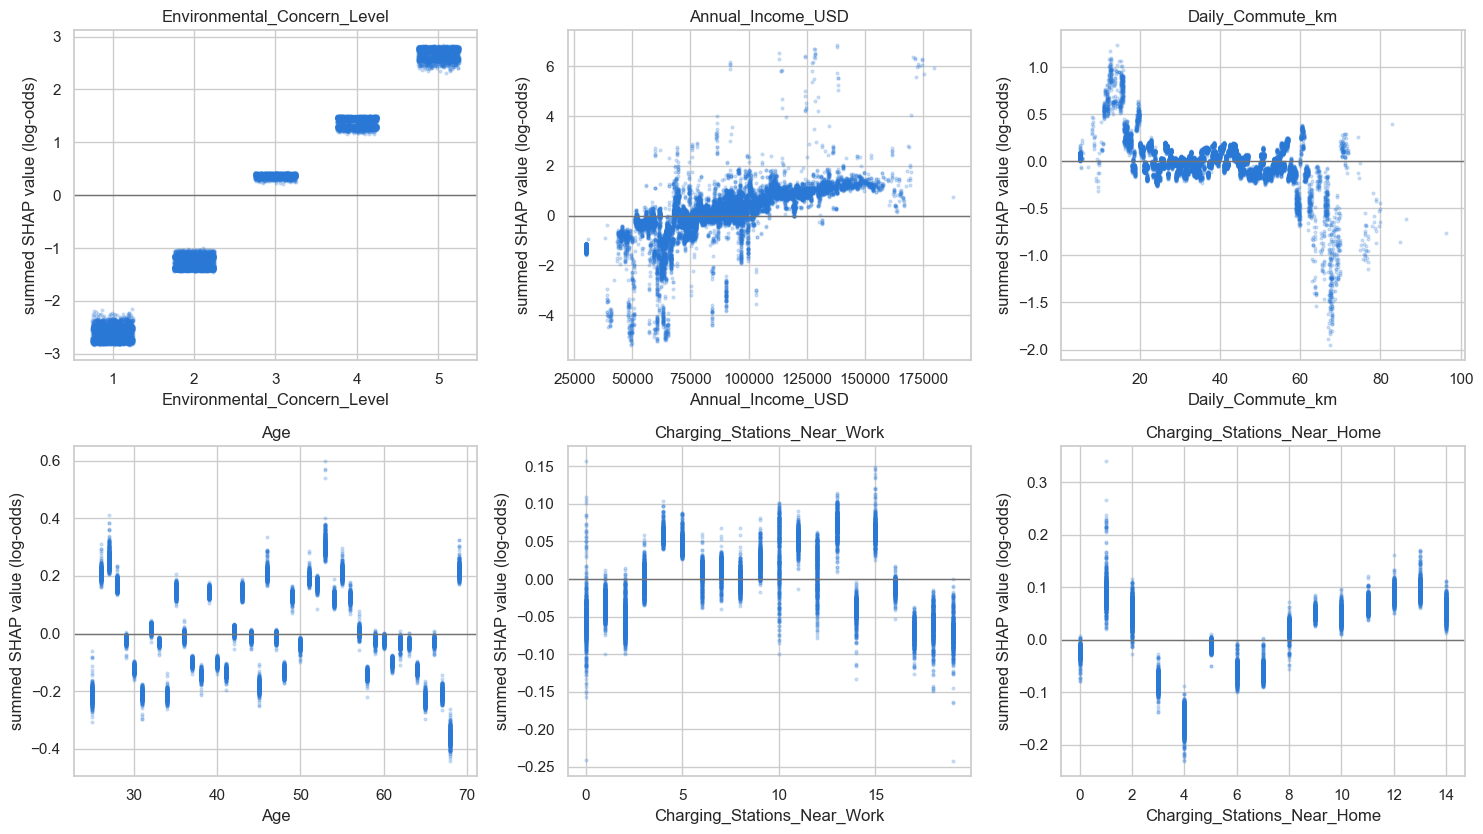

mean summed SHAP value (log-odds)
Subsidy_Available      No                                   -2.563
                       Yes                                   1.500
Range_Anxiety_Level    High                                 -2.889
                       Low                                   0.117
                       Medium                               -1.051
Home_Charging_Possible No                                   -0.137
                       Yes                                   0.060
City_Type              Rural                                -0.021
                       Suburban                             -0.012
                       Urban                                 0.016

In [37]:
dependence_cols = [
    "Environmental_Concern_Level",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Age",
    "Charging_Stations_Near_Work",
    "Charging_Stations_Near_Home",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
for ax, col in zip(axes.flat, dependence_cols):
    x = shap_sample[col].astype(float).values
    if col == "Environmental_Concern_Level":
        x = x + rng.uniform(-0.25, 0.25, len(x))  # jitter the 5 levels so the points are visible
    ax.scatter(x, shap_by_source[col], s=4, alpha=0.2, color=COLORS[0], rasterized=True)
    ax.axhline(0, color="0.45", lw=1)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("summed SHAP value (log-odds)")
plt.tight_layout()
plt.show()

categorical_effects = pd.concat(
    {
        col: shap_by_source[col].groupby(shap_sample[col].astype(str)).mean()
        for col in ["Subsidy_Available", "Range_Anxiety_Level", "Home_Charging_Possible", "City_Type"]
    }
)
categorical_effects.rename("mean summed SHAP value (log-odds)").to_frame().round(3)

**What to check.** Whether the model agrees with the EDA: `Subsidy_Available` and
`Environmental_Concern_Level` should dominate, with concern level pushing predictions up step by step, and
Medium/High range anxiety should push them down. The income panel shows the *identity* effect directly: a
smooth trend with a wide vertical spread at every income level — rows with nearly the same income get
different contributions because their exact values carry different label rates. Commute should show the same
pattern more weakly, and columns without value-level signal (age, station counts) a thin band.

## 11. Diagnostics

For the best final model or blend by OOF AUC: ROC curve and calibration, then AUC inside each EDA segment
compared with the §5 LightGBM baseline — which shows *where* the gains came from.

best model: Blend: LR stacker


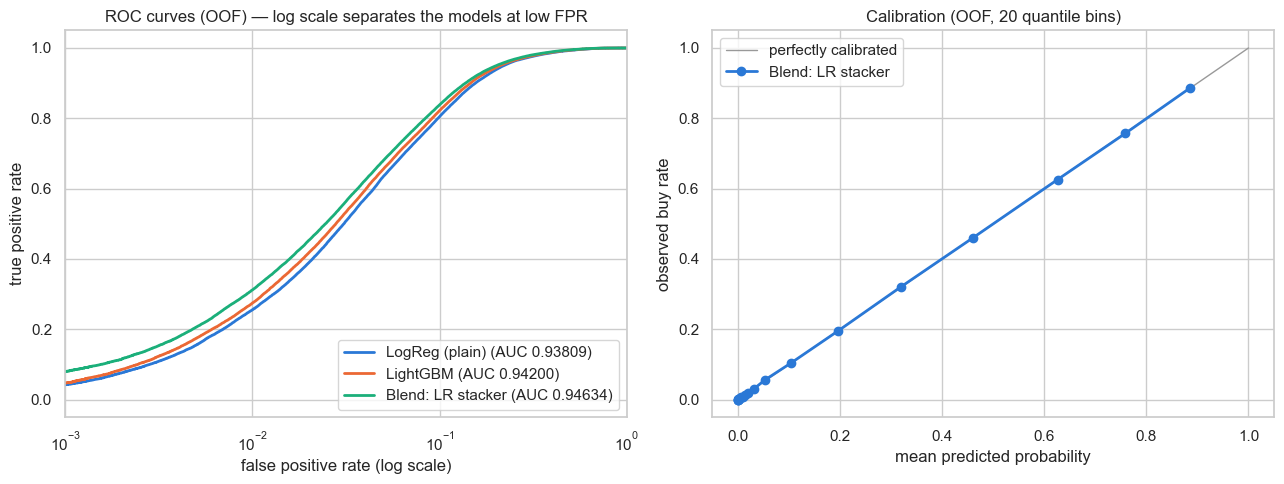

In [38]:
best_name = max(FINAL_CANDIDATES, key=lambda name: results[name]["auc"])
print("best model:", best_name)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for color, name in zip(COLORS, ["LogReg (plain)", "LightGBM", best_name]):
    fpr, tpr, _ = roc_curve(y, results[name]["oof"])
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC {results[name]['auc']:.5f})")
axes[0].set_xscale("log")
axes[0].set_xlim(1e-3, 1)
axes[0].set_xlabel("false positive rate (log scale)")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC curves (OOF) — log scale separates the models at low FPR")
axes[0].legend(loc="lower right")

prob_true, prob_pred = calibration_curve(y, results[best_name]["oof"], n_bins=20, strategy="quantile")
axes[1].plot([0, 1], [0, 1], color="0.6", lw=1, label="perfectly calibrated")
axes[1].plot(prob_pred, prob_true, "o-", color=COLORS[0], lw=2, markersize=6, label=best_name)
axes[1].set_xlabel("mean predicted probability")
axes[1].set_ylabel("observed buy rate")
axes[1].set_title("Calibration (OOF, 20 quantile bins)")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

In [39]:
segment_frame = train[FEATURES].assign(
    Income_at_floor=np.where(train["Annual_Income_USD"] <= INCOME_FLOOR, "yes", "no")
)
rows = []
for col in [
    "Subsidy_Available",
    "Range_Anxiety_Level",
    "Environmental_Concern_Level",
    "Home_Charging_Possible",
    "City_Type",
    "Income_at_floor",
]:
    for level, idx in segment_frame.groupby(col).indices.items():
        if y[idx].min() == y[idx].max():
            continue  # AUC is undefined when a segment has only one class
        rows.append(
            {
                "segment": f"{col} = {level}",
                "rows": len(idx),
                "positives": int(y[idx].sum()),
                "AUC baseline": roc_auc_score(y[idx], results["LightGBM"]["oof"][idx]),
                "AUC best": roc_auc_score(y[idx], results[best_name]["oof"][idx]),
            }
        )
segment_auc = pd.DataFrame(rows).set_index("segment")
segment_auc["gain"] = segment_auc["AUC best"] - segment_auc["AUC baseline"]
segment_auc.round(4)

,rows,positives,AUC baseline,AUC best,gain
segment,,,,,
Subsidy_Available = No,248756,1432,0.8763,0.8865,0.0102
Subsidy_Available = Yes,419909,115347,0.9043,0.9116,0.0073
Range_Anxiety_Level = High,2194,3,0.9833,0.9830,-0.0003
Range_Anxiety_Level = Low,603972,114167,0.9393,0.9438,0.0046
Range_Anxiety_Level = Medium,62499,2609,0.9333,0.9382,0.0050
Environmental_Concern_Level = 1.0,147476,834,0.8259,0.8391,0.0133
Environmental_Concern_Level = 2.0,135133,2889,0.8385,0.8501,0.0116
Environmental_Concern_Level = 3.0,127351,14126,0.8507,0.8655,0.0147
Environmental_Concern_Level = 4.0,130469,32467,0.8658,0.8778,0.0120


**How to read it.** Calibration checks that predicted probabilities match observed buy rates — AUC doesn't
need it, but it matters if the probabilities are ever used directly. In the segment table, AUC *within* a
segment measures ranking among similar people, so most segment AUCs sit below the overall AUC: telling
subsidy from no-subsidy people apart is the easy part. The `gain` column shows where the income features,
tuning and blending helped most. Segments with few buyers (e.g. `Range_Anxiety_Level = High`) have noisy AUCs.

## 12. Submission

The submission uses whichever final model or blend has the best **OOF** AUC. The blends' scores are nested,
so they compete fairly with the single models. Test predictions are already averaged over the 5 fold models.

In [40]:
final_table = pd.Series({name: results[name]["auc"] for name in FINAL_CANDIDATES}).sort_values(ascending=False)
best_name = final_table.index[0]
print(final_table.round(5).to_string())
print(f"\nselected: {best_name}  (OOF AUC {final_table.iloc[0]:.5f})")

submission = pd.DataFrame({"id": test["id"], TARGET: results[best_name]["test_pred"]})
submission.to_csv("submission.csv", index=False)

sample = pd.read_csv(DATA_DIR / "sample_submission.csv")
probs = submission[TARGET]

print()
print("shape matches sample :", submission.shape == sample.shape)
print("ids match sample     :", submission["id"].equals(sample["id"]))
print("columns              :", list(submission.columns))
print(f"prob range           : {probs.min():.5f} - {probs.max():.5f}")
print(f"mean predicted prob  : {probs.mean():.5f} | train positive rate: {y.mean():.5f}")
print("nulls                :", int(probs.isnull().sum()))
submission.head()

Blend: LR stacker                  0.94634
Blend: hill climbing               0.94634
Blend: mean log-odds (boosters)    0.94626
LightGBM (pseudo-labelled TE)      0.94621
XGBoost (tuned)                    0.94621
CatBoost (tuned)                   0.94620
LightGBM (tuned)                   0.94617
CatBoost (narrow features)         0.94609
LogReg (EDA + income)              0.94432

selected: Blend: LR stacker  (OOF AUC 0.94634)



shape matches sample : True
ids match sample     : True
columns              : ['id', 'Will_Buy_EV']
prob range           : 0.00000 - 0.99980
mean predicted prob  : 0.17521 | train positive rate: 0.17465
nulls                : 0


,id,Will_Buy_EV
0,668665,0.032671
1,668666,0.016908
2,668667,0.003550
3,668668,0.001873
4,668669,0.025450


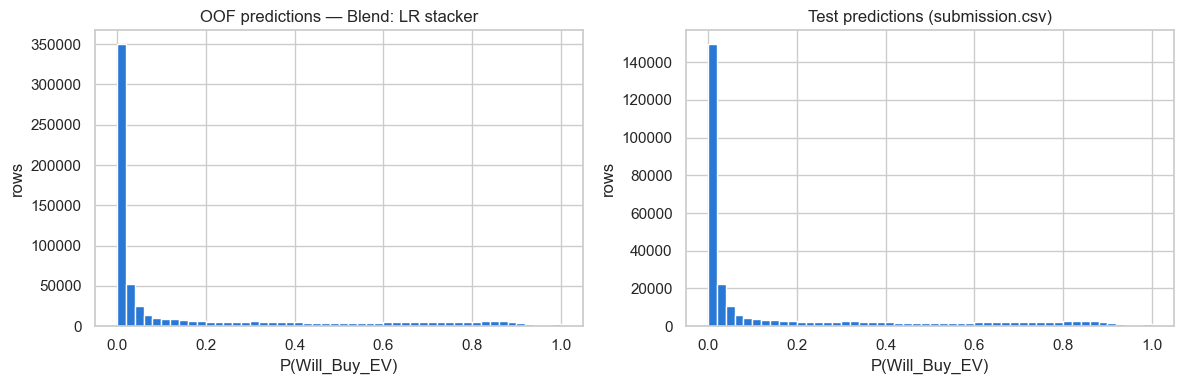

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(results[best_name]["oof"], bins=50, color=COLORS[0])
axes[0].set_title(f"OOF predictions — {best_name}")
axes[1].hist(submission[TARGET], bins=50, color=COLORS[0])
axes[1].set_title("Test predictions (submission.csv)")
for ax in axes:
    ax.set_xlabel("P(Will_Buy_EV)")
    ax.set_ylabel("rows")
plt.tight_layout()
plt.show()

## 13. Summary

In [42]:
summary = (
    pd.DataFrame(
        {
            name: {
                "OOF AUC": r["auc"],
                "fold std": np.std(r["fold_aucs"]),
                "gain vs LogReg (plain)": r["auc"] - results["LogReg (plain)"]["auc"],
                "seconds": r["seconds"],
            }
            for name, r in results.items()
        }
    )
    .T.sort_values("OOF AUC", ascending=False)
    .round({"OOF AUC": 5, "fold std": 5, "gain vs LogReg (plain)": 5, "seconds": 0})
)
print(f"notebook runtime: {(time.time() - NOTEBOOK_START) / 60:.0f} min")
summary

notebook runtime: 79 min


,OOF AUC,fold std,gain vs LogReg (plain),seconds
Blend: LR stacker,0.94634,0.00080,0.00825,5.0
Blend: hill climbing,0.94634,0.00080,0.00824,36.0
Blend: mean log-odds (boosters),0.94626,0.00080,0.00816,0.0
LightGBM (pseudo-labelled TE),0.94621,0.00080,0.00811,849.0
XGBoost (tuned),0.94621,0.00080,0.00811,616.0
CatBoost (tuned),0.94620,0.00079,0.00811,610.0
LightGBM (tuned),0.94617,0.00080,0.00807,507.0
"LightGBM + wide encoding (wide params, 10 folds)",0.94613,0.00080,0.00803,160.0
CatBoost (narrow features),0.94609,0.00083,0.00800,482.0
LightGBM + pseudo-labelled TE,0.94606,0.00060,0.00797,165.0


**The path so far** — numbers from development runs on the same folds and seed; the table above holds this
run's numbers, including the tuned models and blends:

| Step | OOF AUC | What it showed |
|---|---|---|
| Plain logistic regression | 0.93809 | baseline |
| + EDA splines, one-hot, floor flags | 0.93929 | the EDA's non-linear shapes are real (+0.0012) |
| LightGBM, raw features | 0.94200 | trees add +0.0027; XGBoost and CatBoost within 0.0005 |
| LightGBM, depth-1 trees only | 0.94183 | interactions are worth only ~0.0002 |
| + income count | 0.94310 | the generator reuses income values (+0.0011) |
| + income target encoding | 0.94555 | which label goes with a value carries over (+0.0024) |
| XGBoost / CatBoost with the same features, untuned | 0.94561 / 0.94549 | the gain carries over to other libraries |
| + multi-scale bins + magic flags, tuned, blended | 0.94604 | previous version of this notebook (public LB 0.94619) |
| + wide encoding and its LightGBM shape | 0.94597 | every column as a key (+0.00015, half keys / half tree shape) |
| same, 10 folds instead of 5 | 0.94613 | the encodings were starved for rows (+0.00016) |
| tuned boosters + a narrow-feature CatBoost, blended | 0.94628 | four members on 10 folds |
| + a member whose encoders saw pseudo-labelled test rows | 0.94634 | this run — +0.00030 over the previous version |

**Conclusions**
- The EDA picked the right features — subsidy, environmental concern, income, range anxiety — but its
  gate-like subsidy pattern turned out additive on the log-odds scale, so per-segment models and feature
  crosses didn't help.
- The largest gain came from treating income as an *identity*, not only a quantity. That's an artifact of the
  synthetic generator, so don't expect it to transfer to real-world data; within this competition it's
  legitimate, since neither income feature sees validation labels.
- The generator draws each column's values from the original survey's pools without copying whole rows, so
  exact values of every column carry the synthetic data's own label rates. The wide encoding reads them all;
  with that many correlated encodings, a low column sample matters more than the tree shape.
- Target encodings are per-value averages, so they improve with more rows: 10-fold CV beats 5-fold with the
  same model, and the test predictions get the same benefit.
- The value-level signal looks exhausted. Grouping the final model's OOF predictions by exact income value,
  or by (income, commute) and (income, age) pairs, and comparing observed buyers with predicted ones gives a
  residual variance of 0.71–1.01 where pure noise would give 1.00. Whatever those keys carry, the model
  already has it — which is why every further encoding variant in §6 came back flat.
- Ensembling has hit its limit: five of the six members are 0.996+ rank-correlated, so the blend adds
  +0.0001 at most, and nothing beats a linear one. The only member that still pays is the one fitted
  differently (pseudo-labelled encodings), not one tuned differently.
- Ideas that sounded promising but didn't help: floor flags, discrete numerics as categories, appending the
  original survey, target-encoded feature pairs, digit features, the linked survey respondent's label, and a
  neural network on the wide encoding (0.9454 alone, no weight in the blend).
- The members are highly correlated, so blending is a final polish rather than a step change.

**Next ideas:** the cheap levers are spent — 20 folds, a full-data refit, more Optuna trials, richer
encodings and every extra model family were all tested and gave nothing. What is left is either more
compute for very little (extra seeds in `FINAL_SEEDS`, each worth about +0.00002) or a genuinely different
way to read the generator's value pools.